In [1]:
""" import useful functions """
##########################################################################
import os

# set the environment variable to control the number of threads
# NEEDS TO BE DONE BEFORE CCL IS IMPORTED
original_omp_num_threads = os.environ.get('OMP_NUM_THREADS', None)
os.environ['OMP_NUM_THREADS'] = '1'

# Generic
import numpy as np
import pandas as pd
import scipy
from itertools import islice, cycle
import math
import os
import sys
from scipy.integrate import odeint
#from joblib import Parallel, delayed
import itertools
from importlib import reload
from functools import lru_cache
import scipy.integrate
from scipy.interpolate import interpn
from scipy.interpolate import CubicSpline
import gc
from scipy.signal import savgol_filter

# cosmology
import pyccl as ccl
from astropy.io import fits
import yaml
import sacc
import time

# SRD Binning
import srd_redshift_distributions as srd
import binning

# Data Visualization
import matplotlib.pyplot as plt
import matplotlib
#from tabulate import tabulate
from matplotlib.colors import LogNorm
#import seaborn as sns
from matplotlib.lines import Line2D

# HiCOLA background
from HiCOLA.Frontend import expression_builder as eb
import HiCOLA.Frontend.numerical_solver as ns
from HiCOLA.Frontend.read_parameters import read_in_parameters
import sympy as sym

from CubicGalileonFunctions import *


(50, 5)
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48]
This SepiaData instance implies the following:
This is a simulator (eta)-only model, y dimension 768
m  =    49 (number of simulated data)
p  =     1 (number of inputs)
q  =     5 (number of additional simulation inputs)
pu NOT SET (transformed response dimension); call method create_K_basis 

Number of models loaded: 50 from: ../CubicGalileonEmu/CubicGalileonEmu/model/
4.182345109176885e-05
Horndeski functions initialized.


In [2]:
cosmo_testing = ccl.Cosmology(Omega_c = (0.1417493400784 - 0.0223)/0.67**2,
                           Omega_b =  0.0223/0.67**2,
                           h = 0.67,
                           n_s = 0.9665,
                           A_s = 2.01e-9)

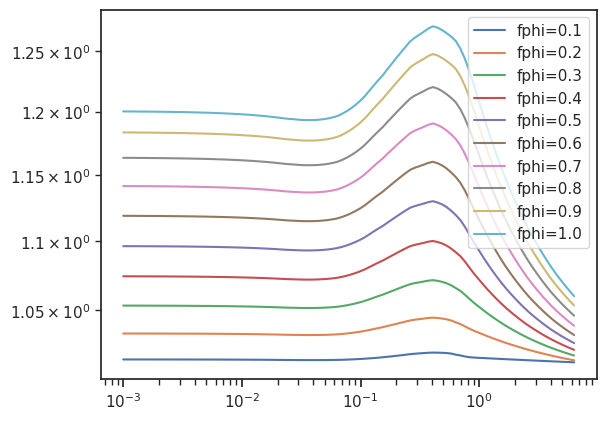

In [3]:
# Example test case

cosmo_testing = ccl.Cosmology(Omega_c = (0.1417493400784 - 0.0223)/0.67**2,
                           Omega_b =  0.0223/0.67**2,
                           h = 0.67,
                           n_s = 0.9665,
                           A_s = 2.01e-9)


P_delta2D_GR_nl_test = Get_Pk2D_obj_kk_GR_nl(cosmo_testing)

a_test = 1
k_test = np.logspace(-3,0.8,100)
f_phi_range = np.linspace(0.1,1.0,10)
for i in range(len(f_phi_range)):
    BkTest_new = B_k_NL_CuGal(f_phi_range[i], cosmo_testing, k_test, a_test)

    plt.loglog(k_test, BkTest_new, label=f"fphi={f_phi_range[i]:.1f}")
plt.legend()
plt.show()

## Cells

In [ ]:
# for interpolation scheme testing:
# Tested to work (~1%): for x_integral --> 2e3, for a_array --> 100, for k_array (both Pk and Cell) --> 200
# Relative to Baseline: 1e4, 150, 1000, 1000

# NL matter power spectra in cG
def P_k_NL_CuGal(GR_pk2D_obj, f_phi, cosmo, k, a):
    """
    input k (array) -> wavevector, units 1/Mpc
    input a (float or array) -> scale factor (1/(1+z))
    input cosmo (cosmology object) -> Cosmology object from CCL
    output Pk_CG (array) -> Nonlinear matter power spectrum for cG gravity, units (Mpc)^3
    """
    k_ext = 1.5 * cosmo["h"]  # k value where we switch to power-law extrapolation
    k_emu = k_all * cosmo["h"]  # emulator k grid in 1/Mpc

    # fixed extrapolation grid, independent of input k
    k_extrap = np.logspace(np.log10(1e-3), np.log10(50), 200)
    k_add_ext = k_extrap[k_extrap > k_ext]   # power-law tail region

    if isinstance(a, (float, int)):  # Single scale factor case
        # if z > 12, set boost to 1
        if 1/a - 1 > 12:
            return GR_pk2D_obj.__call__(k, a=a)
        
        input_params_and_redshift = np.append(
            np.array([cosmo["Omega_m"], cosmo["n_s"], 1e9 * cosmo["A_s"], cosmo["h"], f_phi]),
            1.0 / a - 1.0
        )
        bk_target, err_target = emu_redshift(input_params_and_redshift[np.newaxis, :], sepia_model_list, sepia_data_list, z_all)
        bk_target = bk_target.flatten()

        # interpolate emulator output onto the fixed grid, up to k_ext
        interp_func = scipy.interpolate.interp1d(k_emu, bk_target, kind='linear', fill_value="extrapolate")
        Bk_cut = interp_func(k_extrap[k_extrap <= k_ext])

        # power-law extrapolation matching the slope at the last two points
        #######################################################
        k_cut_ext = k_extrap[k_extrap <= k_ext]
        k0 = k_cut_ext[-1]
        k1 = k_cut_ext[-2]
        x0 = k0 + 1e-5  # add small number to avoid zero division in case k0=k1
        x1 = k1 + 1e-5
        B0 = Bk_cut[-1]
        B1 = Bk_cut[-2]
        # dy/d(log k)
        B0_prime = (B0 - B1) / (x0 - x1)
        # if gradient is positive, set it to zero to avoid unphysical increase in Bk at high k
        B0_prime = np.where(B0_prime > 0, 0, B0_prime)
        # exponent ensuring derivative continuity
        p = -x0 * B0_prime / (B0 - 1)
        A = (B0 - 1) * x0**p
        x_add = k_add_ext + 1e-5
        # log B tail
        Bk_add = A * x_add**(-p) + 1
        bk_extrap = np.append(Bk_cut, Bk_add)
        ########################################################

        # interpolate the consistent extrapolated curve onto the requested k
        out_func = scipy.interpolate.interp1d(k_extrap, bk_extrap, kind='linear', fill_value="extrapolate")
        pkratio_CuGal = out_func(k)

    else:
        bk_target = []
        z_range = 1.0 / a - 1.0  # Array of redshift values
        # Loop over each redshift value
        for z_val in z_range:
            # for any arr > 12, set boost to 1
            if z_val > 12:
                bk_target.append(np.ones_like(k_emu))
            else:
                input_params_and_redshift = np.append(
                    np.array([cosmo["Omega_m"], cosmo["n_s"], 1e9 * cosmo["A_s"], cosmo["h"], f_phi]),
                    z_val
                )
                #print("getting bk_target for z=", z_val)
                bk_target_i, _ = emu_redshift(input_params_and_redshift[np.newaxis, :], sepia_model_list, sepia_data_list, z_all)
                #print("got bk_target for z=", z_val)
                bk_target.append(bk_target_i.flatten())
        # Convert list to array with shape (len(a), len(k_all))
        bk_target = np.array(bk_target)

        # interpolate each row onto the fixed grid, up to k_ext
        k_cut_ext = k_extrap[k_extrap <= k_ext]
        Bk_cut = np.array([
            scipy.interpolate.interp1d(k_emu, bk_row, kind='linear', fill_value="extrapolate")(k_cut_ext)
            for bk_row in bk_target
        ])

        # power-law extrapolation matching the slope at the last two points
        #######################################################
        k0 = k_cut_ext[-1]
        k1 = k_cut_ext[-2]
        x0 = k0 + 1e-5  # add small number to avoid zero division in case k0=k1
        x1 = k1 + 1e-5
        B0 = Bk_cut[:, -1]
        B1 = Bk_cut[:, -2]
        # dy/d(log k)
        B0_prime = (B0 - B1) / (x0 - x1)
        # if gradient is positive, set it to zero to avoid unphysical increase in Bk at high k
        B0_prime = np.where(B0_prime > 0, 0, B0_prime)
        # exponent ensuring derivative continuity
        p = -x0 * B0_prime / (B0 - 1)
        A = (B0 - 1) * x0**p
        x_add = k_add_ext + 1e-5
        # log B tail
        Bk_add = A[:, None] * x_add[None, :]**(-p[:, None]) + 1
        bk_extrap = np.concatenate([Bk_cut, Bk_add], axis=1)
        ########################################################

        # interpolate each extrapolated row onto the requested k
        pkratio_CuGal = np.array([
            scipy.interpolate.interp1d(k_extrap, bk_row, kind='linear', fill_value="extrapolate")(k)
            for bk_row in bk_extrap
        ])    

    Pk_ccl = GR_pk2D_obj.__call__(k, a=a) # units (Mpc)^3
    Pk = pkratio_CuGal*Pk_ccl
    
    return Pk

def Pk_2D_obj_CuGal_deldel(GR_pk2D_obj, f_phi, cosmo,a_arr, UE_arr, coupling_factor_arr):
    """
    input k (array) -> wavevector, units 1/Mpc
    input a (float or array) -> scale factor (1/(1+z))
    input cosmo (cosmology object) -> Cosmology object from CCL
    output Pk_CG_obj (array) -> 2D object forNonlinear matter power spectrum for cG gravity, units (Mpc)^3
    """

    def pk_func(k,a):
        # Compute P(k, a) separately for different tracer combinations
        #print("length array check: ", len(a_array), len(k_array), P_k_NL_CuGal(GR_pk2D_obj,f_phi,cosmo_GR, k_array, np.array([1,1/(0.006636100756698626 + 1)])).shape, mu_cugal_val.shape)
        Pk_NL_kk = P_k_NL_CuGal(GR_pk2D_obj,f_phi,cosmo, k, a)

        return Pk_NL_kk
    
    return ccl.pk2d.Pk2D.from_function(pkfunc=pk_func, is_logp=False)


def Pk_2D_obj_CuGal_kk(pk2D_obj_deldel, f_phi, cosmo,a_arr, UE_arr, coupling_factor_arr):
    """
    input k (array) -> wavevector, units 1/Mpc
    input a (float or array) -> scale factor (1/(1+z))
    input cosmo (cosmology object) -> Cosmology object from CCL
    output Pk_CG_obj (array) -> 2D object forNonlinear matter power spectrum for cG gravity, units (Mpc)^3
    """

    def pk_func(k,a):
        # Compute P(k, a) separately for different tracer combinations
        mu_cugal_val = np.repeat(mu_CuGal(a_arr, coupling_factor_arr, [a])[:, np.newaxis], len(k), axis=1)
        #print("length array check: ", len(a_array), len(k_array), P_k_NL_CuGal(GR_pk2D_obj,f_phi,cosmo_GR, k_array, np.array([1,1/(0.006636100756698626 + 1)])).shape, mu_cugal_val.shape)
        Pk_NL_kk = mu_cugal_val**2 * pk2D_obj_deldel.__call__(k, a=a)
        return Pk_NL_kk
    
    return ccl.pk2d.Pk2D.from_function(pkfunc=pk_func, is_logp=False)
    
def Pk_2D_obj_CuGal_delk(pk2D_obj_deldel, f_phi, cosmo,a_arr, UE_arr, coupling_factor_arr):
    """
    input k (array) -> wavevector, units 1/Mpc
    input a (float or array) -> scale factor (1/(1+z))
    input cosmo (cosmology object) -> Cosmology object from CCL
    output Pk_CG_obj (array) -> 2D object forNonlinear matter power spectrum for cG gravity, units (Mpc)^3
    """

    def pk_func(k,a):
        # Compute P(k, a) separately for different tracer combinations
        mu_cugal_val = np.repeat(mu_CuGal(a_arr, coupling_factor_arr, [a])[:, np.newaxis], len(k), axis=1)
        #print("length array check: ", len(a_array), len(k_array), P_k_NL_CuGal(GR_pk2D_obj,f_phi,cosmo_GR, k_array, np.array([1,1/(0.006636100756698626 + 1)])).shape, mu_cugal_val.shape)
        Pk_NL_kk = mu_cugal_val * pk2D_obj_deldel.__call__(k, a=a)
        return Pk_NL_kk
    
    return ccl.pk2d.Pk2D.from_function(pkfunc=pk_func, is_logp=False)

Save

def Cell_CuGal(ell_binned, a_arr, UE_arr, coupling_factor_arr, f_phi, cosmo_GR, z, 
               Binned_distribution_s, Binned_distribution_l, Bias_distribution,
               pk2D_obj, tracer1_type="k", tracer2_type="k"):
    # Define the scale factor array
    a_array = np.logspace(np.log10(1/14), 0, 100)
    
    # Compute chi using the comoving radial distance function
    chi_array = comoving_radial_dist_CuGal(a_arr, UE_arr, cosmo_GR, a_array)
    
    #plt.plot(a_array, chi_array)

    # Compute h_over_h0 using the Hubble expansion rate function
    h_over_h0_array = E_CuGal(a_arr, UE_arr, a_array)
    
    # Create the background dictionary
    background_dict = {
        'a': a_array,
        'chi': chi_array,
        'h_over_h0': h_over_h0_array
    }

    growthfact_array = growthfactor_CuGal(a_arr, UE_arr, coupling_factor_arr, f_phi, cosmo_GR, a_array)
    growthrate_array = growthrate_CuGal(a_arr, UE_arr, coupling_factor_arr, f_phi, cosmo_GR, a_array)
    
    # Create the growth dictionary
    growth_dict = {
        'a': a_array,
        'growth_factor': growthfact_array,
        'growth_rate': growthrate_array
    }

    k_array = np.logspace(-4, 3, 200)
    
    # Select the correct Pk_NL array
    Pk_NL_selected = pk2D_obj.__call__(k_array, a=a_array)  # This will be the same for all tracer combinations since pk2D_obj is defined to return the correct P(k,a) based on the tracer types
    Pk_NL_dict = {
        'a': a_array,
        'k': k_array,
        'delta_matter:delta_matter': Pk_NL_selected,
    }
    
    # Create the cosmology object
    cosmo = ccl.cosmology.CosmologyCalculator(
        Omega_c=cosmo_GR["Omega_c"],
        Omega_b=cosmo_GR["Omega_b"],
        h=cosmo_GR["h"],
        n_s=cosmo_GR["n_s"],
        A_s=cosmo_GR["A_s"],
        background=background_dict,
        growth=growth_dict,
        pk_nonlin=Pk_NL_dict
    )
    
    # Mapping of tracer combinations to their respective power spectra
    ops = {
        ("k", "k"): C_ell_arr_kk_GR,
        ("k", "g"): C_ell_arr_delk_GR, 
        ("g", "k"): C_ell_arr_delk_GR,
        ("g", "g"): C_ell_arr_deldel_GR
    }

    def invalid_op2():
        raise ValueError('Invalid tracer selection.')

    ########## Compute C_ell ##########

    C_ell_array_funct = ops.get((tracer1_type, tracer2_type), invalid_op2)
    C_ell_array = C_ell_array_funct(ell_binned, cosmo, z, Binned_distribution_s, Binned_distribution_l, Bias_distribution)

    return np.array(list(itertools.chain(*ell_binned))), C_ell_array

### Add a function that lets you use the specific P(k,a) for validation instead of the one from the emulator

def Cell_CuGal_Validation(ell_binned, a_arr, UE_arr, coupling_factor_arr, f_phi, cosmo_GR, z, 
               Binned_distribution_s, Binned_distribution_l, Bias_distribution, 
               GR_pk2D_obj, Bk_CuGal_cosmo_funct, tracer1_type="k", tracer2_type="k"):
    # Define the scale factor array
    a_array = np.logspace(np.log10(1/14), 0, 100)
    
    # Compute chi using the comoving radial distance function
    chi_array = comoving_radial_dist_CuGal(a_arr, UE_arr, cosmo_GR, a_array)
    
    # Compute h_over_h0 using the Hubble expansion rate function
    h_over_h0_array = E_CuGal(a_arr, UE_arr, a_array)
    
    # Create the background dictionary
    background_dict = {
        'a': a_array,
        'chi': chi_array,
        'h_over_h0': h_over_h0_array
    }

    growthfact_array = growthfactor_CuGal(a_arr, UE_arr, coupling_factor_arr, f_phi, cosmo_GR, a_array)
    growthrate_array = growthrate_CuGal(a_arr, UE_arr, coupling_factor_arr, f_phi, cosmo_GR, a_array)
    
    # Create the growth dictionary
    growth_dict = {
        'a': a_array,
        'growth_factor': growthfact_array,
        'growth_rate': growthrate_array
    }

    k_array = np.logspace(-4, 3, 200)

    Pk_ccl = GR_pk2D_obj.__call__(k_array, a=a_array)

    # Compute P(k, a) separately for different tracer combinations
    mu_cugal_val = np.repeat(mu_CuGal(a_arr, coupling_factor_arr, a_array)[:, np.newaxis], len(k_array), axis=1)
    k_array_hMpc = k_array / cosmo_GR["h"]
    Pk_NL_kk = mu_cugal_val**2 * Bk_CuGal_cosmo_funct(1/a_array[::-1] - 1.0, k_array_hMpc)[::-1, :] * Pk_ccl
    Pk_NL_kg = mu_cugal_val * Bk_CuGal_cosmo_funct(1/a_array[::-1] - 1.0, k_array_hMpc)[::-1, :] * Pk_ccl
    Pk_NL_gg = Bk_CuGal_cosmo_funct(1/a_array[::-1] - 1.0, k_array_hMpc)[::-1, :] * Pk_ccl

    # Dictionary to store the correct P(k, a) choice
    Pk_NL_dict_map = {
        ("k", "k"): Pk_NL_kk,
        ("k", "g"): Pk_NL_kg,
        ("g", "k"): Pk_NL_kg,
        ("g", "g"): Pk_NL_gg
    }

    # Select the correct Pk_NL array
    Pk_NL_selected = Pk_NL_dict_map.get((tracer1_type, tracer2_type))
    if Pk_NL_selected is None:
        raise ValueError(f"Invalid tracer combination: ({tracer1_type}, {tracer2_type})")

    Pk_NL_dict = {
        'a': a_array,
        'k': k_array,
        'delta_matter:delta_matter': Pk_NL_selected,
    }
    
    # Create the cosmology object
    cosmo = ccl.cosmology.CosmologyCalculator(
        Omega_c=cosmo_GR["Omega_c"],
        Omega_b=cosmo_GR["Omega_b"],
        h=cosmo_GR["h"],
        n_s=cosmo_GR["n_s"],
        A_s=cosmo_GR["A_s"],
        background=background_dict,
        growth=growth_dict,
        pk_nonlin=Pk_NL_dict
    )
    
    # Mapping of tracer combinations to their respective power spectra
    ops = {
        ("k", "k"): C_ell_arr_kk_GR,
        ("k", "g"): C_ell_arr_delk_GR, 
        ("g", "k"): C_ell_arr_delk_GR,
        ("g", "g"): C_ell_arr_deldel_GR
    }

    def invalid_op2():
        raise ValueError('Invalid tracer selection.')

    ########## Compute C_ell ##########

    C_ell_array_funct = ops.get((tracer1_type, tracer2_type), invalid_op2)
    C_ell_array = C_ell_array_funct(ell_binned, cosmo, z, Binned_distribution_s, Binned_distribution_l, Bias_distribution)

    return np.array(list(itertools.chain(*ell_binned))), C_ell_array

In [321]:
# load cubic galileon functions 
import pyccl as ccl
#################################################################
# 1. Mock redshift distribution
# Define the redshift interval and forecast years
redshift_range = np.linspace(0.01, 3.5, 500)
forecast_years = ["1", "10"]  # Assuming integers are appropriate

# Create a dictionary to store the redshift distributions
# for each forecast year and galaxy sample
redshift_distribution = {
    "sources": {},
    "lenses": {}
}

for year in forecast_years:
    source_dist = srd.SRDRedshiftDistributions(redshift_range, 
                                               galaxy_sample="source_sample",
                                               forecast_year=year)
    lens_dist = srd.SRDRedshiftDistributions(redshift_range, 
                                             galaxy_sample="lens_sample",
                                             forecast_year=year)

    redshift_distribution["sources"][year] = source_dist.get_redshift_distribution(normalised=True,
                                                                                   save_file=False)
    redshift_distribution["lenses"][year] = lens_dist.get_redshift_distribution(normalised=True,
                                                                                save_file=False)

# Uncomment to check if the dictionary is populated correctly
# print(redshift_distribution["sources"].keys())


bins = {
    "sources": {},
    "lenses": {}
}

# Perform the binning procedure
for year in forecast_years:
    bins["sources"][year] = binning.Binning(redshift_range, 
                                            redshift_distribution["sources"][year],
                                            year).source_bins(normalised=True,
                                                              save_file=False)
    bins["lenses"][year] = binning.Binning(redshift_range, 
                                           redshift_distribution["lenses"][year],
                                           year).lens_bins(normalised=True,
                                                           save_file=False)


#(5, 256)
Binned_distribution_lens = [list(bins["lenses"]["1"].items())[0][1]]
for i in range(4):
    Binned_distribution_lens = np.append(Binned_distribution_lens,\
               [list(bins["lenses"]["1"].items())[i+1][1]], axis=0)

Binned_distribution_source = [list(bins["sources"]["1"].items())[0][1]]
for i in range(4):
    Binned_distribution_source = np.append(Binned_distribution_source,\
               [list(bins["sources"]["1"].items())[i+1][1]], axis=0)

z = redshift_range

#################################################################
Bias_distribution_fiducial = np.array([1.562362*np.ones(len(z)),
                             1.732963*np.ones(len(z)),
                             1.913252*np.ones(len(z)),
                             2.100644*np.ones(len(z)),
                             2.293210*np.ones(len(z))])

# define ell and C_ell shapes -- will depend on the data

ell_min_mockdata = 20
ell_max_mockdata = 15000

# define quantities for binning of ell -- will depend on the data

ell_bin_num_mockdata = 20

############# GET COVARIANCE MATRIX #########################
"""Get SRD covariance matrix"""

# covariance for shear bin combinations, in order: z11, z12, z13,..., z15, z22, z23,...z55

########## Get full covariance ##########

covfile = np.genfromtxt("Y1_3x2pt_clusterN_clusterWL_cov")
print(covfile.shape)

shear_SRD = np.zeros((705,705))
ell_test_SRD = np.zeros(705)

for i in range(0,covfile.shape[0]):
    shear_SRD[int(covfile[i,0]),int(covfile[i,1])] = covfile[i,8]+covfile[i,9] # non-gauss
    shear_SRD[int(covfile[i,1]),int(covfile[i,0])] = covfile[i,8]+covfile[i,9] # non-gauss
    if int(covfile[i,0]) == int(covfile[i,1]):
        ell_test_SRD[int(covfile[i,0])] = covfile[i,2]

del covfile
print(shear_SRD.shape)

covariance_matrix = shear_SRD[:540,:540].copy()

# diag errors
diag_cov = np.diag(covariance_matrix)
diag_errors = np.sqrt(diag_cov)

(265275, 10)
(705, 705)


In [322]:

cosmo_universe =  ccl.Cosmology(Omega_c = 0.3137721 - 0.0493017,
                                 Omega_b = 0.0493017,
                                 h = 0.6736,
                                 n_s = 0.9649,
                                 A_s = 2.056248707e-09)

f_phi_universe = np.linspace(0.1, 1.0, 4)
print(f_phi_universe)
D_mockdata_all = []


for i in range(len(f_phi_universe)):
    a_setup_universe, UE_setup_universe, coupling_setup_universe = CuGal_initialize(f_phi_universe[i], cosmo_universe)

    P_delta2D_GR_lin_universe = Get_Pk2D_obj_kk_GR_lin(cosmo_universe)
    P_delta2D_GR_nl_universe = Get_Pk2D_obj_kk_GR_nl(cosmo_universe)
    P_delta2D_cG_nl_deldel_universe = Pk_2D_obj_CuGal_deldel(P_delta2D_GR_nl_universe, f_phi_universe[i], cosmo_universe, a_setup_universe, UE_setup_universe, coupling_setup_universe)
    P_delta2D_cG_nl_kk_universe = Pk_2D_obj_CuGal_kk(P_delta2D_cG_nl_deldel_universe, f_phi_universe[i], cosmo_universe, a_setup_universe, UE_setup_universe, coupling_setup_universe)
    P_delta2D_cG_nl_delk_universe = Pk_2D_obj_CuGal_delk(P_delta2D_cG_nl_deldel_universe, f_phi_universe[i], cosmo_universe, a_setup_universe, UE_setup_universe, coupling_setup_universe)

    """Get mock C(ell) data"""

    ## LENSING - LENSING

    binned_ell = bin_ell_kk(ell_min_mockdata, ell_max_mockdata, ell_bin_num_mockdata, Binned_distribution_source)

    # find C_ell for non-linear matter power spectrum
    mockdata = Cell_CuGal(binned_ell,a_setup_universe, UE_setup_universe, coupling_setup_universe, f_phi_universe[i], cosmo_universe, 
                        z , Binned_distribution_source,Binned_distribution_lens,
                        Bias_distribution_fiducial, P_delta2D_cG_nl_kk_universe, tracer1_type="k", tracer2_type="k")

    ell_kk_mockdata = mockdata[0]
    D_kk_mockdata = mockdata[1]
    D_kk_mockdata = (np.array(D_kk_mockdata)).flatten()

    ## CLUSTERING - LENSING

    binned_ell = bin_ell_delk(ell_min_mockdata, ell_max_mockdata, ell_bin_num_mockdata,Binned_distribution_source,Binned_distribution_lens)

    # find C_ell for non-linear matter power spectrum
    mockdata = Cell_CuGal(binned_ell,a_setup_universe, UE_setup_universe, coupling_setup_universe, f_phi_universe[i],
                        cosmo_universe, z , Binned_distribution_source,Binned_distribution_lens,\
                        Bias_distribution_fiducial,P_delta2D_cG_nl_delk_universe, tracer1_type="k", tracer2_type="g")

    ell_delk_mockdata = mockdata[0]
    D_delk_mockdata = mockdata[1]
    D_delk_mockdata = (np.array(D_delk_mockdata)).flatten()

    ## CLUSTERING - CLUSTERING
    binned_ell = bin_ell_deldel(ell_min_mockdata, ell_max_mockdata, ell_bin_num_mockdata,Binned_distribution_lens)

    # find C_ell for non-linear matter power spectrum
    mockdata = Cell_CuGal(binned_ell,a_setup_universe, UE_setup_universe, coupling_setup_universe, f_phi_universe[i],
                        cosmo_universe, z , Binned_distribution_source,Binned_distribution_lens,\
                        Bias_distribution_fiducial, P_delta2D_cG_nl_deldel_universe, tracer1_type="g", tracer2_type="g")

    ell_deldel_mockdata = mockdata[0]
    D_deldel_mockdata = mockdata[1]
    D_deldel_mockdata = (np.array(D_deldel_mockdata)).flatten()


    ell_mockdata = np.append(np.append(ell_kk_mockdata, ell_delk_mockdata), ell_deldel_mockdata)
    D_mockdata = np.append(np.append(D_kk_mockdata, D_delk_mockdata), D_deldel_mockdata)

    D_mockdata_all.append(D_mockdata)
    del mockdata

[0.1 0.4 0.7 1. ]


In [323]:

cosmo_universe =  ccl.Cosmology(Omega_c = 0.3137721 - 0.0493017,
                                 Omega_b = 0.0493017,
                                 h = 0.6736,
                                 n_s = 0.9649,
                                 A_s = 2.056248707e-09)

cosmo_ecosmog =  ccl.Cosmology(Omega_c = 0.3137721 - 0.0493017,
                                 Omega_b = 0.0493017,
                                 h = 0.6736,
                                 n_s = 0.9649,
                                 A_s = 2.056248707e-09)

f_phi_ecosmog = [1.0]

scale_factors = [0.333333333333, 0.34782608695, 0.36363636363, 0.38095238095, 0.4, 0.42105263157, 0.44444444444, 0.47058823529, 0.5, 0.53333333333,
                0.57142857142, 0.61538461538, 0.66666666666, 0.72727272727, 0.8, 0.88888888888, 1.0]

Bk_vals_sim = []
idx = 1
for i in range(idx, len(scale_factors)+1):
    # format i so that it is 01, 02, etc.
    i_label = str(i+1).zfill(2)
    Pk_ecosmog_phase_1 = np.loadtxt(f"/home/c2042999/Desktop/Newcastle/cG_Forecasts/CubicGalileon_Forecasts/Validation_data/CG_Baojiu_Powmes/Phase1/Pk_CG_Phase1_S000{i_label}_pylians.txt").T
    # remove shape noise, BoxSize**3/Nparticles
    Pk_ecosmog_phase_1[1] = Pk_ecosmog_phase_1[1] - (1024**3/1024**3)
    Pk_ecosmog_phase_2 = np.loadtxt(f"/home/c2042999/Desktop/Newcastle/cG_Forecasts/CubicGalileon_Forecasts/Validation_data/CG_Baojiu_Powmes/Phase2/Pk_CG_Phase2_S000{i_label}_pylians.txt").T
    Pk_ecosmog_phase_2[1] = Pk_ecosmog_phase_2[1] - (1024**3/1024**3)

    Pk_LCDM_ecosmog_phase_1 = np.loadtxt(f"/home/c2042999/Desktop/Newcastle/cG_Forecasts/CubicGalileon_Forecasts/Validation_data/CG_Baojiu_Powmes/LCDMPhase1/Pk_LCDM_Phase1_S000{i_label}_pylians.txt").T
    Pk_LCDM_ecosmog_phase_1[1] = Pk_LCDM_ecosmog_phase_1[1] - (1024**3/1024**3)
    Pk_LCDM_ecosmog_phase_2 = np.loadtxt(f"/home/c2042999/Desktop/Newcastle/cG_Forecasts/CubicGalileon_Forecasts/Validation_data/CG_Baojiu_Powmes/LCDMPhase2/Pk_LCDM_Phase2_S000{i_label}_pylians.txt").T
    Pk_LCDM_ecosmog_phase_2[1] = Pk_LCDM_ecosmog_phase_2[1] - (1024**3/1024**3)

    Bk_vals_sim.append((Pk_ecosmog_phase_1[1]+Pk_ecosmog_phase_2[1])/(Pk_LCDM_ecosmog_phase_1[1]+Pk_LCDM_ecosmog_phase_2[1]))

k_ECOSMOG = Pk_ecosmog_phase_1[0]
Bk_vals_sim = np.array(Bk_vals_sim)
#Bk_CuGal_cosmo_funct_ECOSMOG =  scipy.interpolate.RectBivariateSpline(1/(np.array(scale_factors[4:][::-1])) - 1, k_ECOSMOG, Bk_vals_sim[::-1])

# make Bk_CuGal_cosmo_funct_ECOSMOG so that for k < 2e-2, it is equal to Bk_vals_sim[k=2e-2]
k_ECOSMOG_cut = k_ECOSMOG[k_ECOSMOG > 2e-2]
k_ECOSMOG_cut = k_ECOSMOG_cut[k_ECOSMOG_cut < 4.5]
Bk_vals_sim_cut = Bk_vals_sim[:, k_ECOSMOG > 2e-2]
Bk_vals_sim_cut = Bk_vals_sim_cut[:, k_ECOSMOG[k_ECOSMOG > 2e-2] < 4.5]

# smooth boost
Bk_vals_sim_cut = savgol_filter(Bk_vals_sim_cut, 17, 3, axis=1)

# extrapolate to higher k with a power-law, matching the slope at the last two points
k0 = k_ECOSMOG_cut[-1]
k1 = k_ECOSMOG_cut[-100]
print("k0: ", k0, "k1: ", k1)

x0 = k0 + 1e-1  # add small number to avoid zero division in case k0=k1
x1 = k1 + 1e-1  # add small number to avoid zero division in case k0=k1

B0 = Bk_vals_sim_cut[:, -1]
B1 = Bk_vals_sim_cut[:, -100]

# dy/d(log k)
B0_prime = (B0 - B1) / (x0 - x1)
# if gradient is positive, set it to zero to avoid unphysical increase in Bk at high k
B0_prime = np.where(B0_prime > 0, 0, B0_prime)

# exponent ensuring derivative continuity
p = -x0 * B0_prime / (B0-1)
A = (B0-1) * x0**p

# extension in k
k_add = np.logspace(np.log10(k_ECOSMOG_cut[-1]+1e-1), np.log10(100), 100)  # add k values up to 100 h/Mpc

x_add = k_add + 1e-1

# log B tail
Bk_add = A[:, None] * x_add[None, :]**(-p[:, None]) + 1


Bk_vals_sim_extended = np.concatenate(
    [Bk_vals_sim_cut, Bk_add],
    axis=1
)

k_ECOSMOG_extended = np.concatenate([k_ECOSMOG_cut, k_add])

# add Bk= Bk_emu[0] for z> z_max
z_last = 1/scale_factors[0] - 1
z_asym = np.linspace(12, z_last+1, 10)
Bk_asym =  B_k_NL_CuGal(1.0, cosmo_ecosmog, np.ones(len(k_ECOSMOG_extended))*5e-3, 1/(z_asym+1))

"""
# add Bk reaches 1 at z=10
z_max = 10
print("z_last: ", z_last)
z_asym = np.linspace(z_max, z_last+1e-5, 500)
alpha = ((z_asym - z_max) / (z_last - z_max))[:, None]
Bk_asym = (
    np.ones((len(z_asym), len(k_ECOSMOG_extended)))
    + alpha * (Bk_vals_sim_extended[0] - 1)
)
"""



Bk_vals_sim_extended = np.concatenate(
    [Bk_asym, Bk_vals_sim_extended],
    axis=0
)
"""
z_values_extended = np.append(1/(np.array(scale_factors[idx-1:][::-1])) - 1, 49)
Bk_vals_sim_extended = np.concatenate(
    [Bk_vals_sim_extended[::-1], np.ones((1, len(k_ECOSMOG_extended)))],
    axis=0
)
"""

z_values_extended = np.append(z_asym, 1/(np.array(scale_factors[idx-1:])) - 1)


Bk_CuGal_cosmo_funct_ECOSMOG =  scipy.interpolate.RectBivariateSpline(z_values_extended[::-1],
                                                                       k_ECOSMOG_extended, Bk_vals_sim_extended[::-1])

#Bk_CuGal_cosmo_funct_ECOSMOG =  scipy.interpolate.RectBivariateSpline(1/(np.array(scale_factors[1:][::-1])) - 1, k_ECOSMOG_cut, Bk_emu[::-1])


k0:  4.494540112888964 k1:  3.8870944608703106


In [324]:

D_mockdata_all_ecosmog = []
print(f_phi_ecosmog)

for i in range(len(f_phi_ecosmog)):
    a_setup_ecosmog, UE_setup_ecosmog, coupling_setup_ecosmog = CuGal_initialize(f_phi_ecosmog[i], cosmo_ecosmog)

    P_delta2D_GR_lin_ecosmog = Get_Pk2D_obj_kk_GR_lin(cosmo_ecosmog)
    P_delta2D_GR_nl_ecosmog = Get_Pk2D_obj_kk_GR_nl(cosmo_ecosmog)


    """Get mock C(ell) data - N-body"""

    ## LENSING - LENSING

    binned_ell = bin_ell_kk(ell_min_mockdata, ell_max_mockdata, ell_bin_num_mockdata, Binned_distribution_source)

    # find C_ell for non-linear matter power spectrum
    mockdata = Cell_CuGal_Validation(binned_ell,a_setup_ecosmog, UE_setup_ecosmog, coupling_setup_ecosmog, f_phi_ecosmog[i], cosmo_ecosmog, 
                        z , Binned_distribution_source,Binned_distribution_lens,
                        Bias_distribution_fiducial, P_delta2D_GR_nl_ecosmog, Bk_CuGal_cosmo_funct_ECOSMOG, tracer1_type="k", tracer2_type="k")

    ell_kk_mockdata = mockdata[0]
    D_kk_mockdata_ecosmog = mockdata[1]
    D_kk_mockdata_ecosmog = (np.array(D_kk_mockdata_ecosmog)).flatten()

    ## CLUSTERING - LENSING

    binned_ell = bin_ell_delk(ell_min_mockdata, ell_max_mockdata, ell_bin_num_mockdata,Binned_distribution_source,Binned_distribution_lens)

    # find C_ell for non-linear matter power spectrum
    mockdata = Cell_CuGal_Validation(binned_ell,a_setup_ecosmog, UE_setup_ecosmog, coupling_setup_ecosmog, f_phi_ecosmog[i],
                        cosmo_ecosmog, z , Binned_distribution_source,Binned_distribution_lens,\
                        Bias_distribution_fiducial,P_delta2D_GR_nl_ecosmog, Bk_CuGal_cosmo_funct_ECOSMOG, tracer1_type="k", tracer2_type="g")

    ell_delk_mockdata = mockdata[0]
    D_delk_mockdata_ecosmog = mockdata[1]
    D_delk_mockdata_ecosmog = (np.array(D_delk_mockdata_ecosmog)).flatten()

    ## CLUSTERING - CLUSTERING
    binned_ell = bin_ell_deldel(ell_min_mockdata, ell_max_mockdata, ell_bin_num_mockdata,Binned_distribution_lens)

    # find C_ell for non-linear matter power spectrum
    mockdata = Cell_CuGal_Validation(binned_ell,a_setup_ecosmog, UE_setup_ecosmog, coupling_setup_ecosmog, f_phi_ecosmog[i],
                        cosmo_ecosmog, z , Binned_distribution_source,Binned_distribution_lens,\
                        Bias_distribution_fiducial, P_delta2D_GR_nl_ecosmog, Bk_CuGal_cosmo_funct_ECOSMOG, tracer1_type="g", tracer2_type="g")

    ell_deldel_mockdata = mockdata[0]
    D_deldel_mockdata_ecosmog = mockdata[1]
    D_deldel_mockdata_ecosmog = (np.array(D_deldel_mockdata_ecosmog)).flatten()


    ell_mockdata = np.append(np.append(ell_kk_mockdata, ell_delk_mockdata), ell_deldel_mockdata)
    D_mockdata_ecosmog = np.append(np.append(D_kk_mockdata_ecosmog, D_delk_mockdata_ecosmog), D_deldel_mockdata_ecosmog)

    D_mockdata_all_ecosmog.append(D_mockdata_ecosmog)
    del mockdata

[1.0]


In [325]:

"""Get mock C(ell) data - GR"""

## LENSING - LENSING

binned_ell = bin_ell_kk(ell_min_mockdata, ell_max_mockdata, ell_bin_num_mockdata, Binned_distribution_source)

# find C_ell for non-linear matter power spectrum
mockdata = Cell_GR(binned_ell, cosmo_universe, 
                    z , Binned_distribution_source,Binned_distribution_lens,
                    Bias_distribution_fiducial, tracer1_type="k", tracer2_type="k")

ell_kk_mockdata = mockdata[0]
D_kk_mockdata_GR = mockdata[1]
D_kk_mockdata_GR = (np.array(D_kk_mockdata_GR)).flatten()

## CLUSTERING - LENSING

binned_ell = bin_ell_delk(ell_min_mockdata, ell_max_mockdata, ell_bin_num_mockdata,Binned_distribution_source,Binned_distribution_lens)

# find C_ell for non-linear matter power spectrum
mockdata = Cell_GR(binned_ell, cosmo_universe, 
                    z , Binned_distribution_source,Binned_distribution_lens,
                    Bias_distribution_fiducial, tracer1_type="k", tracer2_type="g")

ell_delk_mockdata = mockdata[0]
D_delk_mockdata_GR = mockdata[1]
D_delk_mockdata_GR = (np.array(D_delk_mockdata_GR)).flatten()

## CLUSTERING - CLUSTERING
binned_ell = bin_ell_deldel(ell_min_mockdata, ell_max_mockdata, ell_bin_num_mockdata,Binned_distribution_lens)

# find C_ell for non-linear matter power spectrum
mockdata = Cell_GR(binned_ell, cosmo_universe, 
                    z , Binned_distribution_source,Binned_distribution_lens,
                    Bias_distribution_fiducial, tracer1_type="g", tracer2_type="g")

ell_deldel_mockdata = mockdata[0]
D_deldel_mockdata_GR = mockdata[1]
D_deldel_mockdata_GR = (np.array(D_deldel_mockdata_GR)).flatten()


ell_mockdata = np.append(np.append(ell_kk_mockdata, ell_delk_mockdata), ell_deldel_mockdata)
D_mockdata_GR = np.append(np.append(D_kk_mockdata_GR, D_delk_mockdata_GR), D_deldel_mockdata_GR)

del mockdata

In [326]:
residual = (D_mockdata_all - D_mockdata_GR)/D_mockdata_GR

residual_ecosmog = (D_mockdata_all_ecosmog - D_mockdata_GR)/D_mockdata_GR

In [327]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch


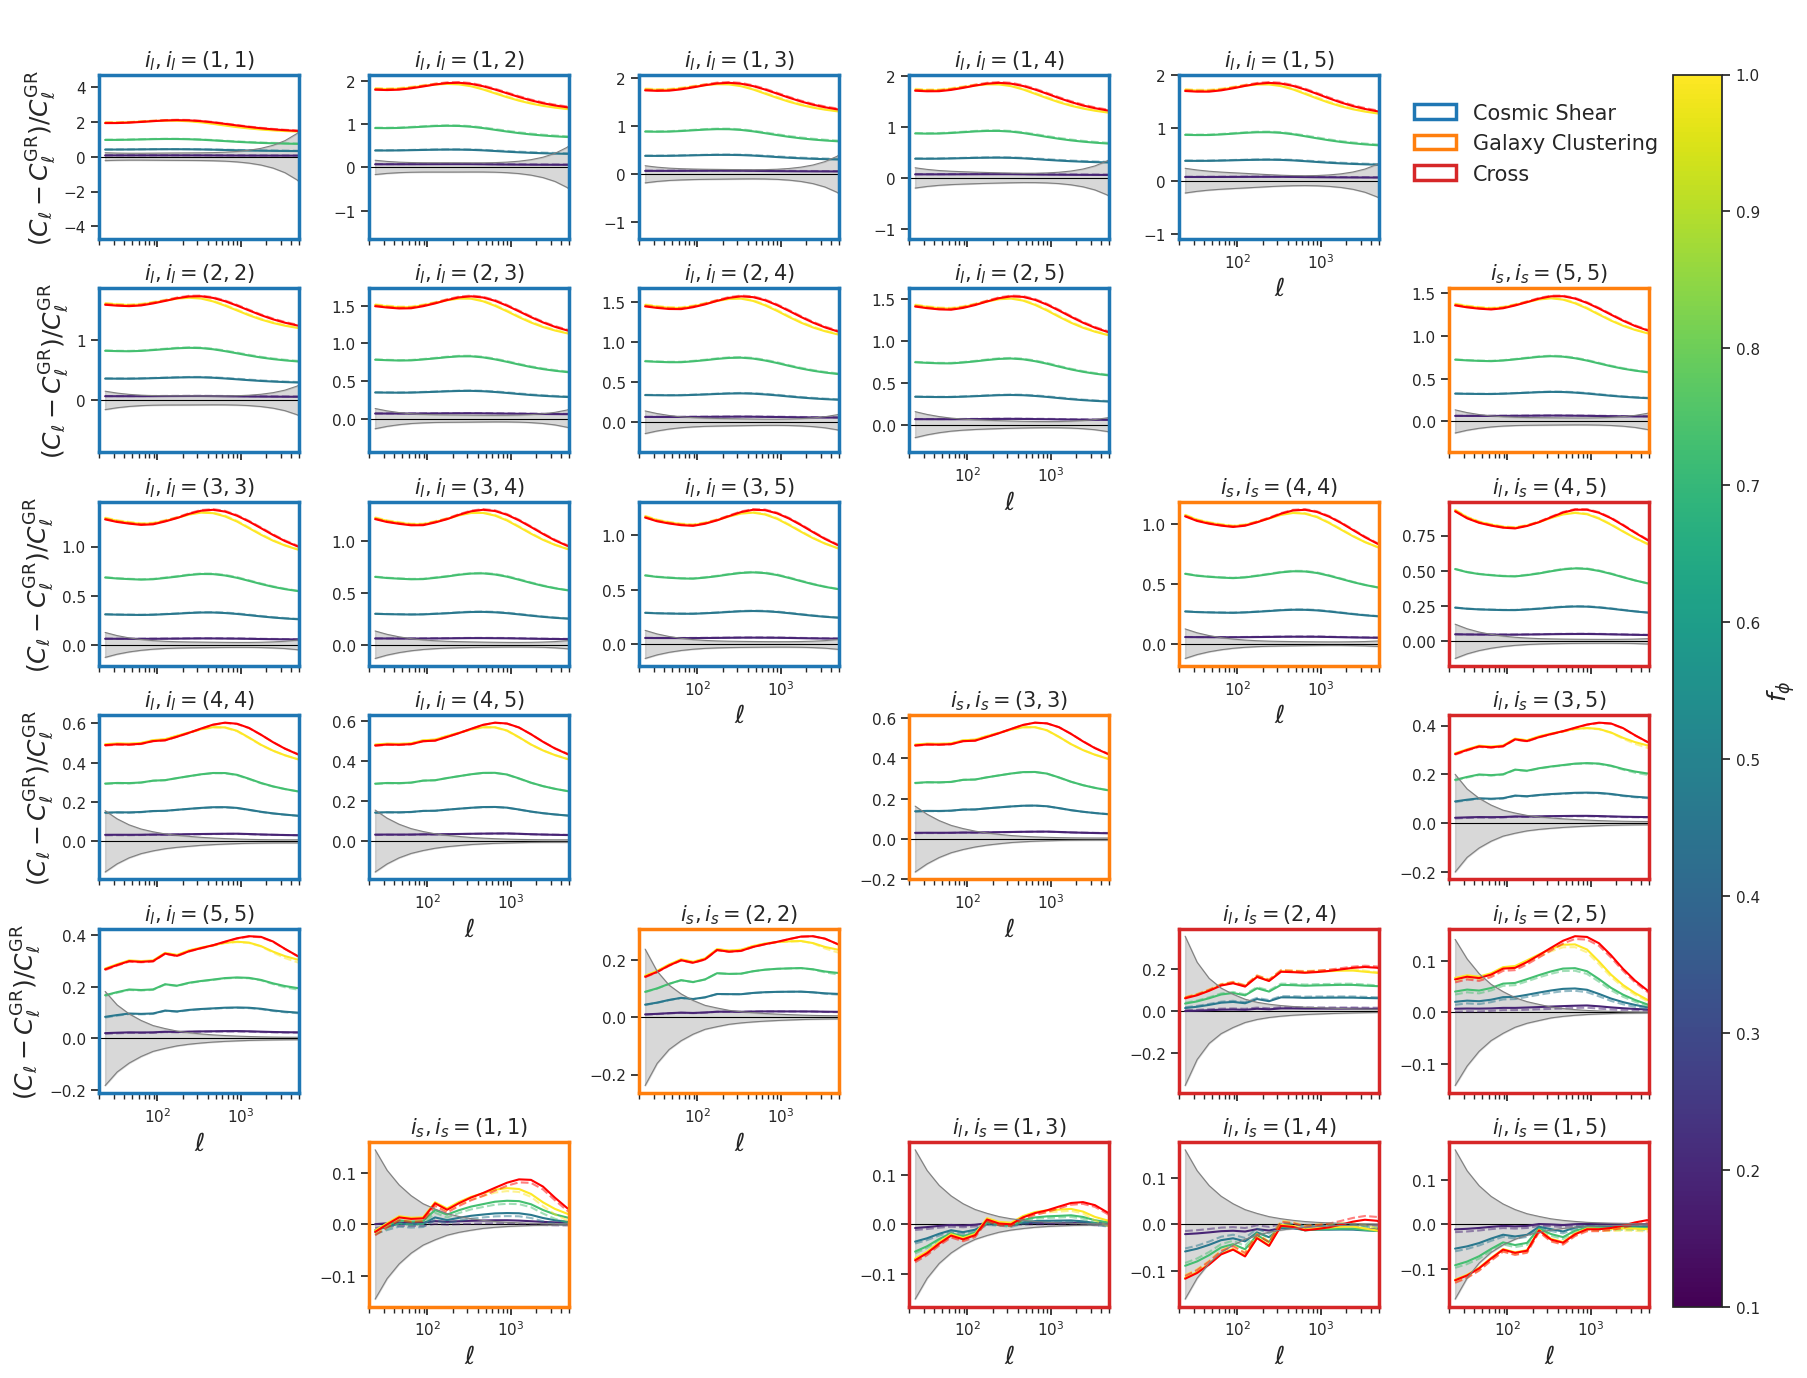

In [328]:

fig = plt.figure(figsize=(20, 16))
outer = gridspec.GridSpec(6, 6, wspace=0.35, hspace=0.3)

titles = [r"$i_l,i_l=(1,1)$",r"$i_l,i_l=(1,2)$",r"$i_l,i_l=(1,3)$",r"$i_l,i_l=(1,4)$",r"$i_l,i_l=(1,5)$",None,
          r"$i_l,i_l=(2,2)$",r"$i_l,i_l=(2,3)$",r"$i_l,i_l=(2,4)$",r"$i_l,i_l=(2,5)$",None,r"$i_s,i_s=(5,5)$",
          r"$i_l,i_l=(3,3)$",r"$i_l,i_l=(3,4)$",r"$i_l,i_l=(3,5)$",None,r"$i_s,i_s=(4,4)$",r"$i_l,i_s=(4,5)$",
          r"$i_l,i_l=(4,4)$",r"$i_l,i_l=(4,5)$",None,r"$i_s,i_s=(3,3)$",None, r"$i_l,i_s=(3,5)$",
          r"$i_l,i_l=(5,5)$",None,r"$i_s,i_s=(2,2)$",None, r"$i_l,i_s=(2,4)$", r"$i_l,i_s=(2,5)$",
          None,r"$i_s,i_s=(1,1)$",None, r"$i_l,i_s=(1,3)$", r"$i_l,i_s=(1,4)$", r"$i_l,i_s=(1,5)$"]

# palette
col_list = matplotlib.colormaps['tab10'].colors
col_list = [col_list[0], col_list[1], col_list[3]]
colors = [col_list[0], col_list[0], col_list[0], col_list[0], col_list[0],
            col_list[0], col_list[0], col_list[0], col_list[0], col_list[0], None, col_list[1],
            col_list[0], col_list[0], col_list[0], None, col_list[1], col_list[2],
            col_list[0], col_list[0], None, col_list[1], None, col_list[2],
            col_list[0], None, col_list[1], None, col_list[2], col_list[2],
            None, col_list[1], None, col_list[2], col_list[2], col_list[2]]

cmap = matplotlib.colormaps['viridis']

datavector_count = 0
for i in range(36):
    row = i // 6
    col = i % 6

    if i in [5, 10,15,20,25,30,32,27,22]:
        continue
    """
    if i == 5:
        # plot the power spectrum boost for this panel, with residual
        inner = gridspec.GridSpecFromSubplotSpec(
            2, 1,
            subplot_spec=outer[row, col],
            height_ratios=[3, 1],
            hspace=0.05
        )
        
        # plot the boost in the main panel
        ax_main = plt.Subplot(fig, inner[0])
        fig.add_subplot(ax_main)
        for j in range(len(f_phi_universe)):
            color = cmap(f_phi_universe[j])
            ax_main.plot(k_test, Boost_universe[j], '-', color=color, markersize=3)
        ax_main.plot(k_test, Boost_GR, '-', color='black', linewidth=1)
        ax_main.set_xscale('log')
        ax_main.set_yscale('log')
        ax_main.set_title(r"$P_\delta^{\text{CuGal}}/P_\delta^{\text{GR}}$", fontsize=15)
        ax_main.tick_params(labelbottom=False)

        # plot the boost residual in the bottom panel
        ax_res = plt.Subplot(fig, inner[1])
        fig.add_subplot(ax_res)
        ax_res.axhline(0, color='black', linewidth=0.8)
        for j in range(len(f_phi_universe)):
            color = cmap(f_phi_universe[j])
            ax_res.plot(k_test, (Boost_universe[j] - Boost_GR)/Boost_GR, '-', color=color, markersize=3)
        ax_res.set_xscale('log')
        continue
    """
    
    inner = gridspec.GridSpecFromSubplotSpec(
        1, 1,
        subplot_spec=outer[row, col]
    )
    
    ax_res = plt.Subplot(fig, inner[0])

    ax_res.set_title(titles[i], fontsize=15)
    # share x-axis for all plots
    fig.add_subplot(ax_res)

    # change color of residual plot
    for spine in ax_res.spines.values():
        spine.set_edgecolor(colors[i])
        spine.set_linewidth(2.5)


    # --- Residual ---
    ax_res.axhline(0, color='black', linewidth=0.8)
    for j in range(len(f_phi_universe)):
        color = cmap(f_phi_universe[j])
        ax_res.plot(ell_mockdata[datavector_count*20: datavector_count*20+20], residual[j][datavector_count*20: datavector_count*20+20], '-', color=color, markersize=3)
        ax_res.plot(ell_mockdata[datavector_count*20: datavector_count*20+20], residual_copy[j][datavector_count*20: datavector_count*20+20], '--', color=color,alpha=0.5, markersize=3)
    # additionally plot residual for ecosmog
    ax_res.plot(ell_mockdata[datavector_count*20: datavector_count*20+20], residual_ecosmog[0][datavector_count*20: datavector_count*20+20], '-', color='red', markersize=3, label='ECOSMOG')
    ax_res.plot(ell_mockdata[datavector_count*20: datavector_count*20+20], residual_ecosmog_copy[0][datavector_count*20: datavector_count*20+20], '--', color='red',alpha=0.5, markersize=3, label='ECOSMOG')

    # additionally plot the error from the covariance
    ax_res.fill_between(ell_mockdata[datavector_count*20: datavector_count*20+20], -diag_errors[datavector_count*20: datavector_count*20+20]/D_mockdata_GR[datavector_count*20: datavector_count*20+20],
                         diag_errors[datavector_count*20: datavector_count*20+20]/D_mockdata_GR[datavector_count*20: datavector_count*20+20], color='grey', alpha=0.3)
    # add lines for fill between
    ax_res.plot(ell_mockdata[datavector_count*20: datavector_count*20+20], diag_errors[datavector_count*20: datavector_count*20+20]/D_mockdata_GR[datavector_count*20: datavector_count*20+20], color='grey', alpha=1.0, linewidth=0.8)
    ax_res.plot(ell_mockdata[datavector_count*20: datavector_count*20+20], -diag_errors[datavector_count*20: datavector_count*20+20]/D_mockdata_GR[datavector_count*20: datavector_count*20+20], color='grey', alpha=1.0, linewidth=0.8)
    ax_res.set_xscale('log')
    datavector_count += 1
    # set x range
    ax_res.set_xlim(20,5000)
    # Clean ticks
    if col == 0:# or (row,col) in [(3,3),(4,2),(2,4),(5,1),(1,5)]:
    # add y label only for first column
        ax_res.set_ylabel(r"$(C_\ell - C_\ell^{\text{GR}})/C_\ell^{\text{GR}}$", fontsize=18)
        #ax_res.set_ylabel(r"$\delta C_\ell/C_\ell^{\text{GR}}$", fontsize=18)
    if row < 5 and (row, col) != (4, 0) and (row, col) != (3, 1) and (row, col) != (2, 2) and (row, col) != (1, 3) and (row, col) != (0, 4) and (row, col) != (3, 3) and (row, col) != (4,2)  and (row, col) != (2,4):
        # no x tick labels except for last row
        ax_res.tick_params(labelbottom=False)
    else:
        ax_res.set_xlabel(r"$\ell$", fontsize=18)


# create a colorbar legend for the cosmologies
ax_all = plt.Subplot(fig, outer[:, :])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=f_phi_universe.min(), vmax=f_phi_universe.max()))
sm.set_array([])
# plot it to the side, size = 0.5*axes size
cbar = plt.colorbar(sm, ax=ax_all, orientation='vertical', anchor=(1.4, 0.5),aspect=25, pad = 0.3)

cbar.set_label(r'$f_\phi$', fontsize=18)

# add legend for color list - col_list[0] = lensing-lensing, col_list[1] = clustering-clustering, col_list[2] = clustering-lensing
legend_elements = [
    Patch(facecolor="white", edgecolor=col_list[0], label='Cosmic Shear', linewidth=2.5),
    Patch(facecolor="white", edgecolor=col_list[1], label='Galaxy Clustering', linewidth=2.5),
    Patch(facecolor="white", edgecolor=col_list[2], label='Cross', linewidth=2.5)
]

fig.legend(handles=legend_elements, loc=(0.778, 0.86), frameon=False, fontsize=15)

#plt.savefig("Figures/CuGal_mockdata_Cells_residuals_Nbody.pdf", bbox_inches="tight")

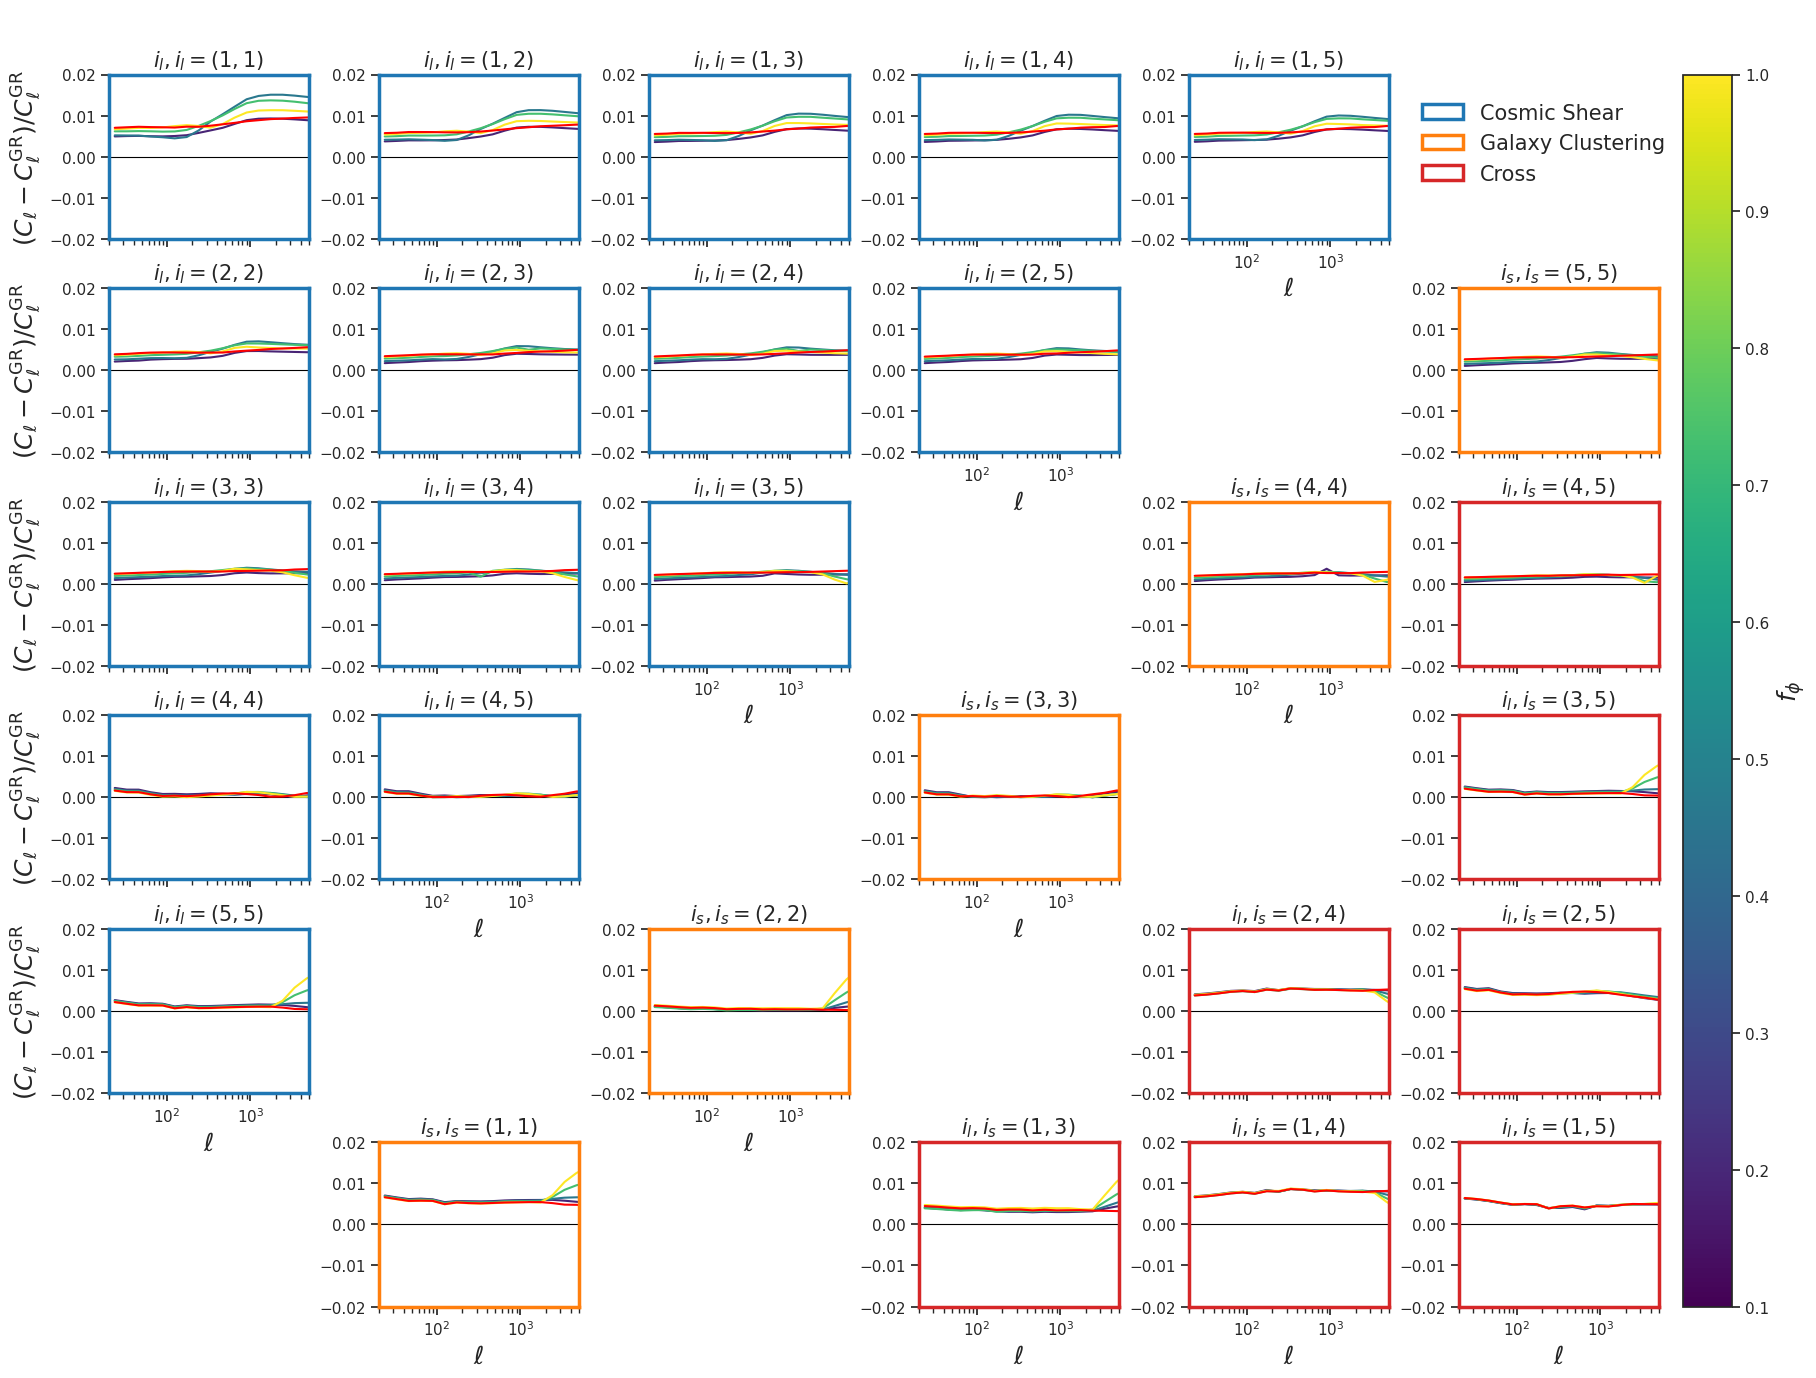

In [329]:
# copy all quantities used in plot 

"""
residual_copy = residual.copy()
D_mockdata_all_copy = D_mockdata_all.copy()
D_mockdata_all_ecosmog_copy = D_mockdata_all_ecosmog.copy()
residual_ecosmog_copy = residual_ecosmog.copy()
ell_mockdata_copy = ell_mockdata.copy()
diag_errors_copy = diag_errors.copy()
D_mockdata_GR_copy = D_mockdata_GR.copy()
"""


fig = plt.figure(figsize=(20, 16))
outer = gridspec.GridSpec(6, 6, wspace=0.35, hspace=0.3)

titles = [r"$i_l,i_l=(1,1)$",r"$i_l,i_l=(1,2)$",r"$i_l,i_l=(1,3)$",r"$i_l,i_l=(1,4)$",r"$i_l,i_l=(1,5)$",None,
          r"$i_l,i_l=(2,2)$",r"$i_l,i_l=(2,3)$",r"$i_l,i_l=(2,4)$",r"$i_l,i_l=(2,5)$",None,r"$i_s,i_s=(5,5)$",
          r"$i_l,i_l=(3,3)$",r"$i_l,i_l=(3,4)$",r"$i_l,i_l=(3,5)$",None,r"$i_s,i_s=(4,4)$",r"$i_l,i_s=(4,5)$",
          r"$i_l,i_l=(4,4)$",r"$i_l,i_l=(4,5)$",None,r"$i_s,i_s=(3,3)$",None, r"$i_l,i_s=(3,5)$",
          r"$i_l,i_l=(5,5)$",None,r"$i_s,i_s=(2,2)$",None, r"$i_l,i_s=(2,4)$", r"$i_l,i_s=(2,5)$",
          None,r"$i_s,i_s=(1,1)$",None, r"$i_l,i_s=(1,3)$", r"$i_l,i_s=(1,4)$", r"$i_l,i_s=(1,5)$"]

# palette
col_list = matplotlib.colormaps['tab10'].colors
col_list = [col_list[0], col_list[1], col_list[3]]
colors = [col_list[0], col_list[0], col_list[0], col_list[0], col_list[0],
            col_list[0], col_list[0], col_list[0], col_list[0], col_list[0], None, col_list[1],
            col_list[0], col_list[0], col_list[0], None, col_list[1], col_list[2],
            col_list[0], col_list[0], None, col_list[1], None, col_list[2],
            col_list[0], None, col_list[1], None, col_list[2], col_list[2],
            None, col_list[1], None, col_list[2], col_list[2], col_list[2]]

cmap = matplotlib.colormaps['viridis']

datavector_count = 0
for i in range(36):
    row = i // 6
    col = i % 6

    if i in [5, 10,15,20,25,30,32,27,22]:
        continue
    
    inner = gridspec.GridSpecFromSubplotSpec(
        1, 1,
        subplot_spec=outer[row, col]
    )
    
    ax_res = plt.Subplot(fig, inner[0])

    ax_res.set_title(titles[i], fontsize=15)
    # share x-axis for all plots
    fig.add_subplot(ax_res)

    # change color of residual plot
    for spine in ax_res.spines.values():
        spine.set_edgecolor(colors[i])
        spine.set_linewidth(2.5)


    # --- Residual ---
    ax_res.axhline(0, color='black', linewidth=0.8)
    for j in range(len(f_phi_universe)):
        color = cmap(f_phi_universe[j])
        # choose smallest between 0.5 and residual/residual_GR - 1 to avoid large outliers dominating the plot, across all ell values in the datavector
        residual_err = np.min([0.5*np.ones(20), np.abs(D_mockdata_all_copy[j][datavector_count*20: datavector_count*20+20] / D_mockdata_all[j][datavector_count*20: datavector_count*20+20] - 1)], axis=0)
        ax_res.plot(ell_mockdata[datavector_count*20: datavector_count*20+20], residual_err, '-', color=color, markersize=3)

    # additionally plot residual for ecosmog
    residual_err_ecosmog = np.min([0.5*np.ones(20), np.abs(D_mockdata_all_ecosmog_copy[0][datavector_count*20: datavector_count*20+20] / D_mockdata_all_ecosmog[0][datavector_count*20: datavector_count*20+20] - 1)], axis=0)
    ax_res.plot(ell_mockdata[datavector_count*20: datavector_count*20+20], residual_err_ecosmog, '-', color='red', markersize=3, label='ECOSMOG')
    # additionally plot the error from the covariance
    #ax_res.fill_between(ell_mockdata[datavector_count*20: datavector_count*20+20], -diag_errors[datavector_count*20: datavector_count*20+20]/D_mockdata_GR[datavector_count*20: datavector_count*20+20],
    #                     diag_errors[datavector_count*20: datavector_count*20+20]/D_mockdata_GR[datavector_count*20: datavector_count*20+20], color='grey', alpha=0.3)
    ax_res.set_xscale('log')
    datavector_count += 1
    # set x range
    ax_res.set_xlim(20,5000)
    ax_res.set_ylim(-0.02, 0.02)
    # Clean ticks
    if col == 0:# or (row,col) in [(3,3),(4,2),(2,4),(5,1),(1,5)]:
    # add y label only for first column
        ax_res.set_ylabel(r"$(C_\ell - C_\ell^{\text{GR}})/C_\ell^{\text{GR}}$", fontsize=18)
        #ax_res.set_ylabel(r"$\delta C_\ell/C_\ell^{\text{GR}}$", fontsize=18)
    if row < 5 and (row, col) != (4, 0) and (row, col) != (3, 1) and (row, col) != (2, 2) and (row, col) != (1, 3) and (row, col) != (0, 4) and (row, col) != (3, 3) and (row, col) != (4,2)  and (row, col) != (2,4):
        # no x tick labels except for last row
        ax_res.tick_params(labelbottom=False)
    else:
        ax_res.set_xlabel(r"$\ell$", fontsize=18)


# create a colorbar legend for the cosmologies
ax_all = plt.Subplot(fig, outer[:, :])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=f_phi_universe.min(), vmax=f_phi_universe.max()))
sm.set_array([])
# plot it to the side, size = 0.5*axes size
cbar = plt.colorbar(sm, ax=ax_all, orientation='vertical', anchor=(1.4, 0.5),aspect=25, pad = 0.3)

cbar.set_label(r'$f_\phi$', fontsize=18)

# add legend for color list - col_list[0] = lensing-lensing, col_list[1] = clustering-clustering, col_list[2] = clustering-lensing
legend_elements = [
    Patch(facecolor="white", edgecolor=col_list[0], label='Cosmic Shear', linewidth=2.5),
    Patch(facecolor="white", edgecolor=col_list[1], label='Galaxy Clustering', linewidth=2.5),
    Patch(facecolor="white", edgecolor=col_list[2], label='Cross', linewidth=2.5)
]

fig.legend(handles=legend_elements, loc=(0.778, 0.86), frameon=False, fontsize=15)

#plt.savefig("Figures/CuGal_mockdata_Cells_residuals_Nbody.pdf", bbox_inches="tight")

# Do MCMC run to understand what is going on

In [ ]:
""" Create forecasts for the cubic galileon model. """

# inputs: params.yaml file (if type = 1, that gives the parameters of the data vector)
#         NOTE: cosmo_validation_edges.txt file (if type = 0, that gives the parameters of the data vector)
#               Boost_validation_edges.txt file (if type = 0, that gives the Boost for the simulated data vector)
#               z_k_validation_edges.txt file (if type = 0, that gives the redshifts and k values for the simulated data vector)
#         config_run.yaml file (that gives the info on the survey, the likelihood, the sampler, and the output chain name)

# outputs: chain file with the forecasted constraints on the parameters
##########################################################################
import os

# set the environment variable to control the number of threads
# NEEDS TO BE DONE BEFORE CCL IS IMPORTED
original_omp_num_threads = os.environ.get('OMP_NUM_THREADS', None)
os.environ['OMP_NUM_THREADS'] = '1'

from CubicGalileonFunctions import *

# Generic
#import pandas as pd
import numpy as np
import scipy
from itertools import islice, cycle
import math
import os
import sys
from scipy.integrate import odeint
#from joblib import Parallel, delayed
import itertools
from importlib import reload
from functools import lru_cache
import scipy.integrate
from scipy.interpolate import interpn
from scipy.interpolate import CubicSpline
from scipy.stats import norm
import gc
from datetime import timedelta

# cosmology
import pyccl as ccl
from astropy.io import fits
import yaml
import sacc
import time

# SRD Binning
import srd_redshift_distributions as srd
import binning

# Data Visualization
import matplotlib.pyplot as plt
#from tabulate import tabulate
from matplotlib.colors import LogNorm
#import seaborn as sns

# Parallelising 
from multiprocessing import Pool
import multiprocessing

# MCMC
from nautilus import Prior, Sampler
import emcee
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import corner
#from chainconsumer import ChainConsumer, Chain, make_sample
from IPython.display import display, Math
from multiprocessing import Pool
#from tqdm import tqdm

# HiCOLA background
from HiCOLA.Frontend import expression_builder as eb
import HiCOLA.Frontend.numerical_solver as ns
from HiCOLA.Frontend.read_parameters import read_in_parameters
import sympy as sym
from scipy.signal import savgol_filter

# Cubic Galileon emu and background
from CubicGalileonEmu.load import *
from CubicGalileonEmu.viz import *
from CubicGalileonEmu.pca import *
from CubicGalileonEmu.gp import *
from CubicGalileonEmu.emu import *
from CubicGalileonEmu.mcmc import *


if_train_all = False ## Re-train all the models. Time-consuming. 
if_mcmc_all = False  ## Full MCMC run. Time-consuming. 
if_savefig = False

from configobj import ConfigObj
import subprocess

# print all versions of imported packages
import types

print("Versions of imported packages:")
for name, module in list(globals().items()):
    if isinstance(module, types.ModuleType):
        version = getattr(module, "__version__", None)
        if version is not None:
            print(f"{name}: {version}")

#################################################################

# Loading CuGal files

Bk_all, Bk_all_smooth, k_all, z_all = load_boost_data()
Bk_lin_all, _, _ = load_boost_data_lin()
p_all = load_params()

print(p_all.shape, flush=True)

## Data prep
z_index = 1

y_vals = Bk_all[:, z_index, :]

# y_ind = np.arange(0, y_vals.shape[1])
y_ind = k_all

# Load validation data

Bk_all_val, Bk_lin_all_val, _, _ = load_boost_data(LIBRARY_BK_FILE_VAL, LIBRARY_ZK_FILE_VAL)
target_vals = Bk_all_val[:, z_index, :]
input_params = load_params(LIBRARY_PARAM_FILE_VAL)

train_indices = [i for i in np.arange(49)] # if i not in test_indices]
print(train_indices, flush=True)

p_all_train = p_all[train_indices]
y_vals_train = Bk_all[:, z_index, :][train_indices]

sepia_data = sepia_data_format(p_all_train, y_vals_train, y_ind)
print(sepia_data)
model_filename = '../CubicGalileonEmu/CubicGalileonEmu/model/multivariate_model_z_index' + str(z_index) 

#sepia_model = do_pca(sepia_data, exp_variance=0.95)
#sepia_model = do_gp_train(sepia_model, model_filename)
#plot_train_diagnostics(sepia_model)

if if_train_all:
    
    do_gp_train_multiple(model_dir='../CubicGalileonEmu/CubicGalileonEmu/model/', 
                        p_train_all = p_all[train_indices],
                        y_vals_all = Bk_all_smooth[train_indices],
                        y_ind_all = k_all,
                        z_index_range=range(49))

sepia_model_list, sepia_data_list = load_model_multiple(model_dir='../CubicGalileonEmu/CubicGalileonEmu/model/', 
                                        p_train_all=p_all[train_indices],
                                        y_vals_all=Bk_all_smooth[train_indices],
                                        y_ind_all=k_all,
                                        z_index_range=range(50))



#################################################################
# 1. Mock redshift distribution
# Define the redshift interval and forecast years
redshift_range = np.linspace(0.01, 3.5, 500)
forecast_years = ["1", "10"]  # Assuming integers are appropriate

# Create a dictionary to store the redshift distributions
# for each forecast year and galaxy sample
redshift_distribution = {
    "sources": {},
    "lenses": {}
}

for year in forecast_years:
    source_dist = srd.SRDRedshiftDistributions(redshift_range, 
                                               galaxy_sample="source_sample",
                                               forecast_year=year)
    lens_dist = srd.SRDRedshiftDistributions(redshift_range, 
                                             galaxy_sample="lens_sample",
                                             forecast_year=year)

    redshift_distribution["sources"][year] = source_dist.get_redshift_distribution(normalised=True,
                                                                                   save_file=False)
    redshift_distribution["lenses"][year] = lens_dist.get_redshift_distribution(normalised=True,
                                                                                save_file=False)

# Uncomment to check if the dictionary is populated correctly
# print(redshift_distribution["sources"].keys())


bins = {
    "sources": {},
    "lenses": {}
}

# Perform the binning procedure
for year in forecast_years:
    bins["sources"][year] = binning.Binning(redshift_range, 
                                            redshift_distribution["sources"][year],
                                            year).source_bins(normalised=True,
                                                              save_file=False)
    bins["lenses"][year] = binning.Binning(redshift_range, 
                                           redshift_distribution["lenses"][year],
                                           year).lens_bins(normalised=True,
                                                           save_file=False)


#(5, 256)
Binned_distribution_lens = [list(bins["lenses"]["1"].items())[0][1]]
for i in range(4):
    Binned_distribution_lens = np.append(Binned_distribution_lens,\
               [list(bins["lenses"]["1"].items())[i+1][1]], axis=0)

Binned_distribution_source = [list(bins["sources"]["1"].items())[0][1]]
for i in range(4):
    Binned_distribution_source = np.append(Binned_distribution_source,\
               [list(bins["sources"]["1"].items())[i+1][1]], axis=0)

z = redshift_range

#################################################################
# get filename from command line
config_file = sys.argv[1]

# read the config file
with open(config_file, 'r') as f:
    config = yaml.safe_load(f)

############# GET SIMULATED DATAVECTOR #########################
params_filename = config['data']['params']

with open(params_filename, 'r') as f:
    params = yaml.safe_load(f)

Bias_distribution_fiducial = np.array([params['b1']*np.ones(len(z)),
                             params['b2']*np.ones(len(z)),
                             params['b3']*np.ones(len(z)),
                             params['b4']*np.ones(len(z)),
                             params['b5']*np.ones(len(z))]
)
cosmo_fid = ccl.Cosmology(Omega_c = 0.269619, 
                          Omega_b = 0.050041,
                          h = 0.6688,
                          n_s = 0.9626,
                          A_s = 2.092e-9)


# if type = 0, read the cosmo file that gives the parameters of the data vector

# define ell and C_ell shapes -- will depend on the data

ell_min_mockdata = 20
ell_max_mockdata = 15000

# define quantities for binning of ell -- will depend on the data

ell_bin_num_mockdata = 20

 ######################### run Cell_CuGal_Validation once to initialize emu #########################
a_setup_universe, UE_setup_universe, coupling_setup_universe = CuGal_initialize(1.0, cosmo_fid)
P_delta2D_GR_lin_universe = Get_Pk2D_obj_kk_GR_lin(cosmo_fid)
P_delta2D_GR_nl_universe = Get_Pk2D_obj_kk_GR_nl(cosmo_fid)

# Get Get mock 3x2pt data
ells_SRD = np.loadtxt("ell-values")

"""Get mock C(ell) data"""

## LENSING - LENSING

binned_ell = bin_ell_kk(ell_min_mockdata, ell_max_mockdata, ell_bin_num_mockdata, Binned_distribution_source)

# find C_ell for non-linear matter power spectrum
mockdata = Cell_CuGal(binned_ell,a_setup_universe, UE_setup_universe, coupling_setup_universe, 1.0, cosmo_fid, 
                        z , Binned_distribution_source,Binned_distribution_lens,
                        Bias_distribution_fiducial, P_delta2D_GR_nl_universe, tracer1_type="k", tracer2_type="k")

del mockdata
##################################################

if config['data']['type'] == 0:
    print("Reading cosmo file to get the parameters of the data vector...")
    txt = config['data']['cosmo_file']
    sim_index = config['data']['index']
    hcube_val_edges  = np.loadtxt(txt).T
    f_phi_val_edges = hcube_val_edges[4][sim_index]
    h_val_edges = hcube_val_edges[3][sim_index]
    Omega_m_val_edges = hcube_val_edges[0][sim_index]
    n_s_val_edges = hcube_val_edges[1][sim_index]
    A_s_val_edges = hcube_val_edges[2][sim_index]

    
    # Load the saved array - gives Boost(i = sample point, z, k)
    Bk_arr_val_edges = np.load(config['data']['data_file'])
    # extract data from text file - gives z and k arrays
    txt_arr_val_edges = np.loadtxt(config['data']['z_k_file'])

    z_arr_val_edges = np.array(txt_arr_val_edges.T[0][np.isfinite(txt_arr_val_edges.T[0])])
    k_arr_val_edges = np.array(txt_arr_val_edges.T[1])*h_val_edges

    Bk_CuGal_cosmo_funct =  scipy.interpolate.RectBivariateSpline(z_arr_val_edges, k_arr_val_edges, Bk_arr_val_edges[sim_index])

    # Define cosmology -- our "universe cosmology"

    cosmo_universe = ccl.Cosmology(Omega_c = Omega_m_val_edges - 0.0223/h_val_edges**2,
                                Omega_b = 0.0223/h_val_edges**2,
                                h = h_val_edges,
                                n_s = n_s_val_edges,
                                A_s = A_s_val_edges)

    cosmo_universe_linear = ccl.Cosmology(Omega_c = Omega_m_val_edges - 0.0223/h_val_edges**2,
                                Omega_b = 0.0223/h_val_edges**2,
                                h = h_val_edges,
                                n_s = n_s_val_edges,
                                A_s = A_s_val_edges,
                                matter_power_spectrum='linear')


    f_phi_universe = f_phi_val_edges
    a_setup_universe, UE_setup_universe, coupling_setup_universe = CuGal_initialize(f_phi_universe, cosmo_universe)

    P_delta2D_GR_lin_universe = Get_Pk2D_obj_kk_GR_lin(cosmo_universe)
    P_delta2D_GR_nl_universe = Get_Pk2D_obj_kk_GR_nl(cosmo_universe)

    # Get Get mock 3x2pt data
    ells_SRD = np.loadtxt("ell-values")


    """Get mock C(ell) data"""

    ## LENSING - LENSING

    binned_ell = bin_ell_kk(ell_min_mockdata, ell_max_mockdata, ell_bin_num_mockdata, Binned_distribution_source)

    # find C_ell for non-linear matter power spectrum
    mockdata = Cell_CuGal_Validation(binned_ell,a_setup_universe, UE_setup_universe, coupling_setup_universe, f_phi_universe, cosmo_universe, 
                        z , Binned_distribution_source,Binned_distribution_lens,
                        Bias_distribution_fiducial, P_delta2D_GR_nl_universe, Bk_CuGal_cosmo_funct, tracer1_type="k", tracer2_type="k")

    ell_kk_mockdata = mockdata[0]
    D_kk_mockdata = mockdata[1]
    D_kk_mockdata = (np.array(D_kk_mockdata)).flatten()

    ## CLUSTERING - LENSING

    binned_ell = bin_ell_delk(ell_min_mockdata, ell_max_mockdata, ell_bin_num_mockdata,Binned_distribution_source,Binned_distribution_lens)

    # find C_ell for non-linear matter power spectrum
    mockdata = Cell_CuGal_Validation(binned_ell,a_setup_universe, UE_setup_universe, coupling_setup_universe, f_phi_universe,
                        cosmo_universe, z , Binned_distribution_source,Binned_distribution_lens,\
                        Bias_distribution_fiducial,P_delta2D_GR_nl_universe, Bk_CuGal_cosmo_funct, tracer1_type="k", tracer2_type="g")

    ell_delk_mockdata = mockdata[0]
    D_delk_mockdata = mockdata[1]
    D_delk_mockdata = (np.array(D_delk_mockdata)).flatten()

    ## CLUSTERING - CLUSTERING
    binned_ell = bin_ell_deldel(ell_min_mockdata, ell_max_mockdata, ell_bin_num_mockdata,Binned_distribution_lens)

    # find C_ell for non-linear matter power spectrum
    mockdata = Cell_CuGal_Validation(binned_ell,a_setup_universe, UE_setup_universe, coupling_setup_universe, f_phi_universe,
                        cosmo_universe, z , Binned_distribution_source,Binned_distribution_lens,\
                        Bias_distribution_fiducial, P_delta2D_GR_nl_universe, Bk_CuGal_cosmo_funct, tracer1_type="g", tracer2_type="g")

    ell_deldel_mockdata = mockdata[0]
    D_deldel_mockdata = mockdata[1]
    D_deldel_mockdata = (np.array(D_deldel_mockdata)).flatten()


    ell_mockdata = np.append(np.append(ell_kk_mockdata, ell_delk_mockdata), ell_deldel_mockdata)
    D_mockdata = np.append(np.append(D_kk_mockdata, D_delk_mockdata), D_deldel_mockdata)

    del mockdata




# if type = 1, read the params file that gives the parameters of the data vector
elif config['data']['type'] == 1:
    print("Reading params file to get the parameters of the data vector...")
    params_filename = config['data']['params']
    with open(params_filename, 'r') as f:
        params = yaml.safe_load(f)
    Omega_m = params['Omega_m']
    Omega_b = params['Omega_b']
    h = params['h']
    n_s = params['ns']
    A_s = params['1e9As']*1e-9
    f_phi_universe = params['f_phi']

    # Define cosmology -- our "universe cosmology"

    cosmo_universe = ccl.Cosmology(Omega_c = Omega_m - Omega_b, 
                            Omega_b = Omega_b,
                            h = h,
                            n_s = n_s,
                            A_s = A_s)
    cosmo_universe_linear = ccl.Cosmology(Omega_c = Omega_m - Omega_b, 
                            Omega_b = Omega_b,
                            h = h,
                            n_s = n_s,
                            A_s = A_s,
                            matter_power_spectrum='linear')

    a_setup_universe, UE_setup_universe, coupling_setup_universe = CuGal_initialize(f_phi_universe, cosmo_universe)

    P_delta2D_GR_lin_universe = Get_Pk2D_obj_kk_GR_lin(cosmo_universe)
    P_delta2D_GR_nl_universe = Get_Pk2D_obj_kk_GR_nl(cosmo_universe)


    """Get mock C(ell) data"""

    ## LENSING - LENSING

    binned_ell = bin_ell_kk(ell_min_mockdata, ell_max_mockdata, ell_bin_num_mockdata, Binned_distribution_source)

    # find C_ell for non-linear matter power spectrum
    mockdata = Cell_CuGal(binned_ell,a_setup_universe, UE_setup_universe, coupling_setup_universe, f_phi_universe, cosmo_universe, 
                        z , Binned_distribution_source,Binned_distribution_lens,
                        Bias_distribution_fiducial, P_delta2D_GR_nl_universe, tracer1_type="k", tracer2_type="k")

    ell_kk_mockdata = mockdata[0]
    D_kk_mockdata = mockdata[1]
    D_kk_mockdata = (np.array(D_kk_mockdata)).flatten()

    ## CLUSTERING - LENSING

    binned_ell = bin_ell_delk(ell_min_mockdata, ell_max_mockdata, ell_bin_num_mockdata,Binned_distribution_source,Binned_distribution_lens)

    # find C_ell for non-linear matter power spectrum
    mockdata = Cell_CuGal(binned_ell,a_setup_universe, UE_setup_universe, coupling_setup_universe, f_phi_universe,
                        cosmo_universe, z , Binned_distribution_source,Binned_distribution_lens,\
                        Bias_distribution_fiducial,P_delta2D_GR_nl_universe, tracer1_type="k", tracer2_type="g")

    ell_delk_mockdata = mockdata[0]
    D_delk_mockdata = mockdata[1]
    D_delk_mockdata = (np.array(D_delk_mockdata)).flatten()

    ## CLUSTERING - CLUSTERING
    binned_ell = bin_ell_deldel(ell_min_mockdata, ell_max_mockdata, ell_bin_num_mockdata,Binned_distribution_lens)

    # find C_ell for non-linear matter power spectrum
    mockdata = Cell_CuGal(binned_ell,a_setup_universe, UE_setup_universe, coupling_setup_universe, f_phi_universe,
                        cosmo_universe, z , Binned_distribution_source,Binned_distribution_lens,\
                        Bias_distribution_fiducial, P_delta2D_GR_nl_universe, tracer1_type="g", tracer2_type="g")

    ell_deldel_mockdata = mockdata[0]
    D_deldel_mockdata = mockdata[1]
    D_deldel_mockdata = (np.array(D_deldel_mockdata)).flatten()


    ell_mockdata = np.append(np.append(ell_kk_mockdata, ell_delk_mockdata), ell_deldel_mockdata)
    D_mockdata = np.append(np.append(D_kk_mockdata, D_delk_mockdata), D_deldel_mockdata)

    del mockdata

# use ecosmog sim, hardcoded for now, to get the boost for the simulated data vector
elif config['data']['type'] == 2:
    print("Reading params file to get the parameters of the data vector...")
    params_filename = config['data']['params']
    with open(params_filename, 'r') as f:
        params = yaml.safe_load(f)
    Omega_m = params['Omega_m']
    Omega_b = params['Omega_b']
    h = params['h']
    n_s = params['ns']
    A_s = params['1e9As']*1e-9
    f_phi_universe = params['f_phi']

    cosmo_universe =  ccl.Cosmology(Omega_c = Omega_m - Omega_b,
                                 Omega_b = Omega_b,
                                 h = h,
                                 n_s = n_s,
                                 A_s = A_s)
    cosmo_universe_linear = ccl.Cosmology(Omega_c = Omega_m - Omega_b, 
                            Omega_b = Omega_b,
                            h = h,
                            n_s = n_s,
                            A_s = A_s,
                            matter_power_spectrum='linear')
    
    scale_factors = config['data']['scale_factors']

    ## GET THE BOOST INTERPOLATED FROM THE SIMULATED DATA ###
    Bk_vals_sim = []
    idx = 1
    name_format = config['data']['name_format']
    name_format_LCDM = config['data']['name_format_LCDM']
    folder_name = config['data']['folder_name']

    for i in range(idx, len(scale_factors)+1):
        # format i so that it is 01, 02, etc.
        i_label = str(i+1).zfill(2)
        Pk_ecosmog_phase_1 = np.loadtxt(f"{folder_name}/Phase1/{name_format.format('1', i_label)}").T
        # remove shape noise, BoxSize**3/Nparticles
        Pk_ecosmog_phase_1[1] = Pk_ecosmog_phase_1[1] - (1024**3/1024**3)
        Pk_ecosmog_phase_2 = np.loadtxt(f"{folder_name}/Phase2/{name_format.format('2', i_label)}").T
        Pk_ecosmog_phase_2[1] = Pk_ecosmog_phase_2[1] - (1024**3/1024**3)

        Pk_LCDM_ecosmog_phase_1 = np.loadtxt(f"{folder_name}/LCDMPhase1/{name_format_LCDM.format('1', i_label)}").T
        Pk_LCDM_ecosmog_phase_1[1] = Pk_LCDM_ecosmog_phase_1[1] - (1024**3/1024**3)
        Pk_LCDM_ecosmog_phase_2 = np.loadtxt(f"{folder_name}/LCDMPhase2/{name_format_LCDM.format('2', i_label)}").T
        Pk_LCDM_ecosmog_phase_2[1] = Pk_LCDM_ecosmog_phase_2[1] - (1024**3/1024**3)

        Bk_vals_sim.append((Pk_ecosmog_phase_1[1]+Pk_ecosmog_phase_2[1])/(Pk_LCDM_ecosmog_phase_1[1]+Pk_LCDM_ecosmog_phase_2[1]))

    k_ECOSMOG = Pk_ecosmog_phase_1[0]
    Bk_vals_sim = np.array(Bk_vals_sim)

    # make Bk_CuGal_cosmo_funct_ECOSMOG so that for k < 2e-2, it is equal to Bk_vals_sim[k=2e-2]
    k_ECOSMOG_cut = k_ECOSMOG[k_ECOSMOG > 2e-2]
    k_ECOSMOG_cut = k_ECOSMOG_cut[k_ECOSMOG_cut < 4]
    Bk_vals_sim_cut = Bk_vals_sim[:, k_ECOSMOG > 2e-2]
    Bk_vals_sim_cut = Bk_vals_sim_cut[:, k_ECOSMOG[k_ECOSMOG > 2e-2] < 4]

    # smooth boost
    Bk_vals_sim_cut = savgol_filter(Bk_vals_sim_cut, 17, 3, axis=1)

    # extrapolate to higher k with a power-law, matching the slope at the last two points
    k0 = k_ECOSMOG_cut[-1]
    k1 = k_ECOSMOG_cut[-100]
    x0 = k0 + 1e-1  # add small number to avoid zero division in case k0=k1
    x1 = k1 + 1e-1  # add small number to avoid zero division in case k0=k1
    B0 = Bk_vals_sim_cut[:, -1]
    B1 = Bk_vals_sim_cut[:, -100]
    # dy/d(log k)
    B0_prime = (B0 - B1) / (x0 - x1)
    # if gradient is positive, set it to zero to avoid unphysical increase in Bk at high k
    B0_prime = np.where(B0_prime > 0, 0, B0_prime)
    # exponent ensuring derivative continuity
    p = -x0 * B0_prime / (B0-1)
    A = (B0-1) * x0**p
    # extension in k
    k_add = np.logspace(np.log10(k_ECOSMOG_cut[-1]+1e-1), np.log10(100), 100)  # add k values up to 100 h/Mpc
    x_add = k_add + 1e-1
    # log B tail
    Bk_add = A[:, None] * x_add[None, :]**(-p[:, None]) + 1
    Bk_vals_sim_extended = np.concatenate(
        [Bk_vals_sim_cut, Bk_add],
        axis=1
    )
    k_ECOSMOG_extended = np.concatenate([k_ECOSMOG_cut, k_add])
    # add Bk= Bk_emu[0] for z> z_max
    z_last = 1/scale_factors[0] - 1
    z_asym = np.linspace(12, z_last+1, 10)
    Bk_asym =  B_k_NL_CuGal(1.0, cosmo_universe, np.ones(len(k_ECOSMOG_extended))*5e-3, 1/(z_asym+1))

    Bk_vals_sim_extended = np.concatenate(
        [Bk_asym, Bk_vals_sim_extended],
        axis=0
    )
    z_values_extended = np.append(z_asym, 1/(np.array(scale_factors[idx-1:])) - 1)
    Bk_CuGal_cosmo_funct_ECOSMOG =  scipy.interpolate.RectBivariateSpline(z_values_extended[::-1],
                                                                        k_ECOSMOG_extended, Bk_vals_sim_extended[::-1])

    #########################################################

    a_setup_ecosmog, UE_setup_ecosmog, coupling_setup_ecosmog = CuGal_initialize(f_phi_universe, cosmo_universe)

    P_delta2D_GR_lin_ecosmog = Get_Pk2D_obj_kk_GR_lin(cosmo_universe)
    P_delta2D_GR_nl_ecosmog = Get_Pk2D_obj_kk_GR_nl(cosmo_universe)


    """Get mock C(ell) data - N-body"""

    ## LENSING - LENSING

    binned_ell = bin_ell_kk(ell_min_mockdata, ell_max_mockdata, ell_bin_num_mockdata, Binned_distribution_source)

    # find C_ell for non-linear matter power spectrum
    mockdata = Cell_CuGal_Validation(binned_ell,a_setup_ecosmog, UE_setup_ecosmog, coupling_setup_ecosmog, f_phi_universe, cosmo_universe, 
                        z , Binned_distribution_source,Binned_distribution_lens,
                        Bias_distribution_fiducial, P_delta2D_GR_nl_ecosmog, Bk_CuGal_cosmo_funct_ECOSMOG, tracer1_type="k", tracer2_type="k")

    ell_kk_mockdata = mockdata[0]
    D_kk_mockdata = mockdata[1]
    D_kk_mockdata = (np.array(D_kk_mockdata)).flatten()

    ## CLUSTERING - LENSING

    binned_ell = bin_ell_delk(ell_min_mockdata, ell_max_mockdata, ell_bin_num_mockdata,Binned_distribution_source,Binned_distribution_lens)

    # find C_ell for non-linear matter power spectrum
    mockdata = Cell_CuGal_Validation(binned_ell,a_setup_ecosmog, UE_setup_ecosmog, coupling_setup_ecosmog, f_phi_universe,
                        cosmo_universe, z , Binned_distribution_source,Binned_distribution_lens,\
                        Bias_distribution_fiducial,P_delta2D_GR_nl_ecosmog, Bk_CuGal_cosmo_funct_ECOSMOG, tracer1_type="k", tracer2_type="g")

    ell_delk_mockdata = mockdata[0]
    D_delk_mockdata = mockdata[1]
    D_delk_mockdata = (np.array(D_delk_mockdata)).flatten()

    ## CLUSTERING - CLUSTERING
    binned_ell = bin_ell_deldel(ell_min_mockdata, ell_max_mockdata, ell_bin_num_mockdata,Binned_distribution_lens)

    # find C_ell for non-linear matter power spectrum
    mockdata = Cell_CuGal_Validation(binned_ell,a_setup_ecosmog, UE_setup_ecosmog, coupling_setup_ecosmog, f_phi_universe,
                        cosmo_universe, z , Binned_distribution_source,Binned_distribution_lens,\
                        Bias_distribution_fiducial, P_delta2D_GR_nl_ecosmog, Bk_CuGal_cosmo_funct_ECOSMOG, tracer1_type="g", tracer2_type="g")

    ell_deldel_mockdata = mockdata[0]
    D_deldel_mockdata = mockdata[1]
    D_deldel_mockdata = (np.array(D_deldel_mockdata)).flatten()


    ell_mockdata = np.append(np.append(ell_kk_mockdata, ell_delk_mockdata), ell_deldel_mockdata)
    D_mockdata = np.append(np.append(D_kk_mockdata, D_delk_mockdata), D_deldel_mockdata)

    del mockdata

else:
    raise ValueError("Invalid data type specified in config file. Must be 0, 1 or 2.")



############# GET COVARIANCE MATRIX #########################
"""Get SRD covariance matrix"""

# covariance for shear bin combinations, in order: z11, z12, z13,..., z15, z22, z23,...z55

########## Get full covariance (gauss only) ##########

covfile = np.genfromtxt("Y1_3x2pt_clusterN_clusterWL_cov")
print(covfile.shape)

shear_SRD = np.zeros((705,705))
ell_test_SRD = np.zeros(705)

for i in range(0,covfile.shape[0]):
    shear_SRD[int(covfile[i,0]),int(covfile[i,1])] = covfile[i,8]+covfile[i,9] # non-gauss
    shear_SRD[int(covfile[i,1]),int(covfile[i,0])] = covfile[i,8]+covfile[i,9] # non-gauss
    if int(covfile[i,0]) == int(covfile[i,1]):
        ell_test_SRD[int(covfile[i,0])] = covfile[i,2]

del covfile
print(shear_SRD.shape)

SRD_compare = shear_SRD[:540,:540].copy()

"""Get mock C(ell) data"""

## LENSING - LENSING

binned_ell = bin_ell_kk(ell_min_mockdata, ell_max_mockdata, ell_bin_num_mockdata, Binned_distribution_source)

# find C_ell for non-linear matter power spectrum
mockdata = Cell_GR(binned_ell, \
                cosmo_fid, z , Binned_distribution_source,Binned_distribution_lens,Bias_distribution_fiducial,\
                tracer1_type="k", tracer2_type="k")

ell_kk_mockdata = mockdata[0]
D_kk_mockdata_test = mockdata[1]
D_kk_mockdata_test = (np.array(D_kk_mockdata_test)).flatten()

print(D_kk_mockdata_test.shape)
del mockdata

k_max = config['specs']['scale_cuts']['max_GC'] # in h/Mpc
ell_cut = config['specs']['scale_cuts']['max_WL'] # in ell

# apply scale cuts
newdat = scale_cuts(cosmo_fid, ell_mockdata,D_mockdata, D_kk_mockdata_test, SRD_compare, k_max, ell_cut)

gauss_invcov_rotated = np.linalg.pinv(SRD_compare)

for i in range(len(newdat)):
    gauss_invcov_rotated[newdat[i]] = np.zeros(len(gauss_invcov_rotated[0]))
    gauss_invcov_rotated[:,newdat[i]] = np.zeros(len(gauss_invcov_rotated[0]))

# WITHOUT NOISE
C_ell_data_mock = [D_mockdata, ell_mockdata, z,  Binned_distribution_source,\
                   Binned_distribution_lens, ell_min_mockdata, ell_max_mockdata, ell_bin_num_mockdata]


######################## LIKELIHOOD ################################

def log_likelihood(theta_dict, Data, invcovmat):
    theta = [float(theta_dict[key]) for key in ["Omega_m", "f_phi", "1e9As", "h", "ns", "Omega_b", "b1", "b2", "b3", "b4", "b5"]]

    Omega_m, f_phi, A_s1e9, h, n_s, Omega_b, b1, b2, b3, b4, b5 = theta 
    Bias_distribution = np.array([b1*np.ones(len(z)),
                             b2*np.ones(len(z)),
                             b3*np.ones(len(z)),
                             b4*np.ones(len(z)),
                             b5*np.ones(len(z))])
    #h = cosmo_universe["h"]
    #A_s = cosmo_universe["A_s"]
    A_s = A_s1e9*1e-9
    #n_s = cosmo_universe["n_s"]
    Omega_c = Omega_m - Omega_b

    cosmoMCMCstep = ccl.Cosmology(Omega_c = Omega_c, 
                      Omega_b = Omega_b,
                      h = h,
                      n_s = n_s,
                      A_s = A_s)
    return loglikelihood(Data, cosmoMCMCstep, f_phi, invcovmat, Bias_distribution)



#### Get Planck priors #####
sampler_Planck_arr = np.load("Prior_Planck_arr.npy")
mu_prior = [cosmo_universe['n_s'], cosmo_universe["Omega_b"]*cosmo_universe["h"]**2]
cov_prior = np.cov(sampler_Planck_arr.T)

with open(config['data']['params'], 'r') as f:
        params = yaml.safe_load(f)

# add additional bespoke priors if needed
def log_prior(theta_dict):
    theta = [float(theta_dict[key]) for key in ["Omega_m", "f_phi", "1e9As", "h", "ns", "Omega_b", "b1", "b2", "b3", "b4", "b5"]]
    Omega_c, f_phi, A_s1e9, h, n_s, Omega_b, b1, b2, b3, b4, b5 = theta 
    priors = params['priors']
    if not priors['Planck_prior']:
        return 0.0
    gauss_funct = scipy.stats.multivariate_normal(mu_prior, cov_prior)
    
    return gauss_funct.logpdf([n_s, Omega_b*h**2])

# add standard priors
prior = Prior()
params_list = ["Omega_m", "f_phi", "1e9As", "h", "ns", "Omega_b", "b1", "b2", "b3", "b4", "b5"]
for par_i in params_list:
    prior.add_parameter(par_i, dist=(params['priors'][par_i][0], params['priors'][par_i][1]))


def log_probability(theta):
    # theta in format [Omega_m, f_phi, A_s1e9, h, n_s, Omega_b, b1, b2, b3, b4, b5]

    theta_dict = {key: theta[i] for i, key in enumerate(params_list)}

    lp = log_prior(theta_dict)
    if not np.isfinite(lp):
        return -np.inf
    try:
        ll = log_likelihood(theta_dict, C_ell_data_mock, gauss_invcov_rotated)
    except ccl.errors.CCLError:
        print("pyccl error for theta:", theta_dict)
        return -np.inf
    if not np.isfinite(ll):
        return -np.inf
    return lp + ll

################## RUN MCMC ########################
# Set the random seed for reproducibility
np.random.seed(10)

"""
# Initialize the walkers
Omega_m_est = 0.3
h_est = 0.68
A_s1e9_est = 3
n_s_est = 0.96
f_phi_est = 0.6
Omega_b_est = 0.0502
b1_est = Bias_distribution_fiducial[0][0] 
b2_est = Bias_distribution_fiducial[1][0]
b3_est = Bias_distribution_fiducial[2][0]
b4_est = Bias_distribution_fiducial[3][0]
b5_est = Bias_distribution_fiducial[4][0]

n_steps = 15000
chain_len = 100
converged = False
nwalkers = 40

# Initialize the walkers
pos = [Omega_m_est, f_phi_est, A_s1e9_est, h_est, n_s_est, Omega_b_est,b1_est,b2_est,b3_est,b4_est,b5_est] \
+ np.append(np.append(1e-3 * np.random.randn(nwalkers, 4), 1e-5*np.random.randn(nwalkers, 2), axis = 1), \
            1e-3 * np.random.randn(nwalkers, 5), axis = 1)

nwalkers, ndim = pos.shape
print(nwalkers, ndim)
"""
# Create the output directory and set up the HDF5 backend
mcmc_dir = "mcmc"
#filename = mcmc_dir + "/ " + config['output']['chain_name'] + ".h5"
#backend = emcee.backends.HDFBackend(filename)

# Optionally reset the backend if starting a new run
#backend.reset(nwalkers, ndim)

print("Running MCMC...")
# Ensure the directories exist
os.makedirs('mcmc', exist_ok=True)
os.makedirs('mcmc/hdf5', exist_ok=True)

"""
def main():
    sampler = Sampler(prior, log_probability, 
                      filepath= mcmc_dir + "/" + config['output']['chain_name'] +'.hdf5', resume=config['sampler']['mcmc']['resume'], n_live=config['sampler']['mcmc']['n_live'], pool=Pool(multiprocessing.cpu_count()))
    start = time.time()
    sampler.run(verbose=bool(config['sampler']['mcmc']['verbose']), discard_exploration=True, n_eff=float(config['sampler']['mcmc']['n_eff']))
    log_z = sampler.evidence()
    points, log_w, log_l = sampler.posterior()
    finish = time.time()
    chain_time = finish-start

    # save header information with Obervable = 3x2pt, LSST Y1, and infromation about scale cuts, parameter values and priors, datavector type/file/index

    header = "# Observable = 3x2pt, LSST Y1 \n" + "# Scale cuts: k_max = {k_max} h/Mpc, ell_max = {ell_cut} \n".format(k_max=k_max, ell_cut=ell_cut) + \
    "# Parameter values and priors: \n" + "# Omega_m = {Omega_m}, f_phi = {f_phi}, A_s = {A_s}, h = {h}, n_s = {n_s}, Omega_b = {Omega_b}, b1 = {b1}, b2 = {b2}, b3 = {b3}, b4 = {b4}, b5 = {b5} \n".format(
        Omega_m=cosmo_universe["Omega_m"], f_phi=f_phi_universe, A_s=cosmo_universe["A_s"], h=cosmo_universe["h"], n_s=cosmo_universe["n_s"], Omega_b=cosmo_universe["Omega_b"], b1=Bias_distribution_fiducial[0][0], b2=Bias_distribution_fiducial[1][0], b3=Bias_distribution_fiducial[2][0], b4=Bias_distribution_fiducial[3][0], b5=Bias_distribution_fiducial[4][0]) + \
    "# Priors: \n" + "# Omega_m: {Omega_m_prior} \n".format(Omega_m_prior=str(params['priors']['Omega_m'])) + \
    "# f_phi: {f_phi_prior} \n".format(f_phi_prior=str(params['priors']['f_phi'])) + \
    "# A_s: {A_s_prior} \n".format(A_s_prior=str(params['priors']['1e9As'])) + \
    "# h: {h_prior} \n".format(h_prior=str(params['priors']['h'])) + \
    "# n_s: {n_s_prior} \n".format(n_s_prior=str(params['priors']['ns'])) + \
    "# Omega_b: {Omega_b_prior} \n".format(Omega_b_prior=str(params['priors']['Omega_b'])) + \
    "# b1: {b1_prior} \n".format(b1_prior=str(params['priors']['b1'])) + \
    "# b2: {b2_prior} \n".format(b2_prior=str(params['priors']['b2'])) + \
    "# b3: {b3_prior} \n".format(b3_prior=str(params['priors']['b3'])) + \
    "# b4: {b4_prior} \n".format(b4_prior=str(params['priors']['b4'])) + \
    "# b5: {b5_prior} \n".format(b5_prior=str(params['priors']['b5'])) + "Planck priors on n_s and wb: {Planck_prior} \n".format(Planck_prior=str(params['priors']['Planck_prior'])) + \
    "# Datavector type: {datavector_type} \n".format(datavector_type="from params file" if config['data']['type'] == 1 else "from cosmo file") + \
    "# Datavector file/index (if from cosmo file): {datavector_info} \n".format(datavector_info="file: " + config['data']['cosmo_file'] + ", index: " + str(config['data']['index']) if config['data']['type'] == 0 else "N/A")

    np.savetxt("chains/chain_"+config['output']['chain_name']+".txt", np.c_[points, log_w, log_l], header=header, footer='log_Z = {log_z};  chain_time = {chain_time} (--> {chain_time_hms} hh:mm:ss)'.format(log_z=log_z, chain_time=chain_time, chain_time_hms=timedelta(seconds=chain_time)))
"""

In [ ]:
##### Set the random seed for reproducibility
from multiprocessing import cpu_count


np.random.seed(10)

# Initialize the walkers
# theta in format [Omega_m, f_phi, A_s1e9, h, n_s, Omega_b, b1, b2, b3, b4, b5]
Omega_m_est = cosmo_universe["Omega_m"]
h_est = cosmo_universe["h"]
A_s1e9_est =  cosmo_universe["A_s"]*1e9
n_s_est = cosmo_universe["n_s"]
f_phi_est = f_phi_universe
Omegab_est =  cosmo_universe["Omega_b"]
b1_est = Bias_distribution_fiducial[0][0]
b2_est = Bias_distribution_fiducial[1][0]
b3_est = Bias_distribution_fiducial[2][0]
b4_est = Bias_distribution_fiducial[3][0]
b5_est = Bias_distribution_fiducial[4][0]

n_steps = 15000
chain_len = 100
converged = False
nwalkers = 80
print(cpu_count())
# Initialize the walkers
pos = [Omega_m_est, f_phi_est, A_s1e9_est, h_est, n_s_est, Omegab_est,b1_est,b2_est,b3_est,b4_est,b5_est] \
+ np.append(np.append(1e-3 * np.random.randn(nwalkers, 5), 1e-5*np.random.randn(nwalkers, 2), axis = 1), \
            1e-3 * np.random.randn(nwalkers, 5), axis = 1)

nwalkers, ndim = pos.shape
print(nwalkers, ndim)

# Create the output directory and set up the HDF5 backend
mcmc_dir = "mcmc"
filename = mcmc_dir + "/mcmc_ESS_muSigma_PCACuts_Sigma1_noparam_mild_fRonly.h5"
backend = emcee.backends.HDFBackend(filename)

# Optionally reset the backend if starting a new run
#backend.reset(nwalkers, ndim)

with Pool(nwalkers) as pool:
    sampler_PCA = emcee.EnsembleSampler(nwalkers, ndim, log_probability, backend=backend, pool=pool)
    pos = sampler_PCA.get_last_sample() if backend.iteration > 0 else pos

    while not converged:
        gc.collect(generation=0)
        sampler_PCA.run_mcmc(pos, chain_len, progress=True, store=True)
        
        # Clear references in the worker pool
        pool.close()
        pool.join()
        del pool  # Ensure the pool object is removed
        gc.collect()  # Collect any lingering garbage
        pool = Pool(nwalkers)
        sampler_PCA.pool = pool
        pos = sampler_PCA.get_last_sample() if backend.iteration > 0 else pos
        
        # Check convergence
        try:
            tau = sampler_PCA.get_autocorr_time(tol=0)
            converged = np.all(tau * 100 < sampler_PCA.iteration)
        except emcee.autocorr.AutocorrError:
            pass
